# Habitat Mapping
- first try of Habitat mapping based on the 'Phytosociological Vegetation Survey'
- Created on 10/16/2025
- Remote sensing data and field data
- Random Forest Classification/Regression

- Updates on 2/3/2026
- PlanetScope Image were downloaded for 03272025, 14 scenes
- Field traning data were pre-processed in Arcgis and summarized in R, 112 were used in Bouarfa

- **Updates on 3/16/2026, normalized habitat names**


# 3rd Edition - Habitat Classification Workflow — Eastern Morocco



## Notes
- All processing is implemented in **Google Earth Engine Python API**  
- Care is taken to ensure **predictor bands match image bands** and avoid masking issues  
- Terrain layers are resampled to match Sentinel-2 10 m resolution  
- Masked pixels are handled carefully to avoid zero sample size errors
- defining Habitat Year 2025 = September 2024–August 2025. That captures the full autumn–winter–spring vegetation cycle much better than your previous March-only composite.

# 2nd Edition - Habitat Classification Workflow — Bouarfa Study Area

## Overview
This notebook implements a **Random Forest (RF) classification workflow** for high-resolution habitat mapping in the Bouarfa study area. The workflow integrates **field-based phytosociological survey data**, **multi-sensor remote sensing imagery**, and **topographic/terrain metrics**.

---

## Dataset

### 1. Field Data
- `Vegetation Phytosociological Survey-1015.csv` (1,945 valid records after removing 74 records with `Area_M2 = 0` or missing)  
- 212 plots for Bouarfa area  
- Standardized **Habitat_Synthesis** types used to create training polygons  
- Fields include: `Habitat`, `Latitude`, `Longitude`, `Area_M2`, `Elevation`, `Slope_Clas`, `Vegetation`, etc.

### 2. Remote Sensing Data
- **Sentinel-2** (March 2025) for classification  
- **Sentinel-2** (September 2024) for water masking (NDWI)  
- Optional: PlanetScope imagery for high-resolution comparison  
- Spectral indices computed: NDVI, EVI, MSAVI, SAVI, NDMI, NBR, NDWI, etc.  
- Cloud masking applied (`QA60`, `MSK_CLDPRB`, `MSK_SNWPRB`)  

### 3. Topographic / Ancillary Layers
- **Copernicus DEM (GLO30)**  
- Derived metrics: Slope, Aspect, Hillshade, [optional Terrain Ruggedness Index (TRI)]
- **Human anthropized areas (from Ecology team)**, Polygons
- **Waterways from Open Street Map**, Polygons
- **Buildings + Popluated areas from Open Street Map, Polygons**

---

## Workflow Steps

### STEP 1 — Field Data Preparation
- Standardize phytosociological plots  
- Convert plots to **training polygons**  
- Encode habitat classes (`class_id`) for RF  

### STEP 2 — Remote Sensing Data Processing
- Clip Sentinel-2 images to study area  
- Apply cloud mask and QA filters  
- Compute vegetation and disturbance indices  
- Calculate September NDWI → derive **water mask**

### STEP 3 — Feature Stack Assembly
- Stack predictor bands:  
  - Spectral bands: B2, B3, B4, B8, B11, B12  
  - Vegetation indices: NDVI, EVI, MSAVI, SAVI, NDMI, NBR  
  - Optional terrain bands: Elevation, Slope, Aspect, Hillshade, [TRI] 
  - Optional masks: Water mask, Vegetation mask  

### STEP 4 — Sampling
- Sample predictor values from training polygons  
- Stratified split: 70% training, 30% testing  

### STEP 5 — Random Forest Classification
- Train RF classifier using training samples  
- Number of trees: 500  
- Evaluate accuracy: confusion matrix, Kappa, F1 per class  
- Compute variable importance  

### STEP 6 — Post-Classification Refinement
- Apply water mask (September NDWI)  
- Apply vegetation mask (optional)  
- Apply majority filter to remove isolated pixels  

### STEP 7 — Outputs
- High-resolution habitat map (10 m)  
- Classification accuracy metrics  
- Variable importance for predictor analysis  
- Optional: multi-year change detection and habitat transition mapping  

---

## Notes
- All processing is implemented in **Google Earth Engine Python API**  
- Care is taken to ensure **predictor bands match image bands** and avoid masking issues  
- Terrain layers are resampled to match Sentinel-2 10 m resolution  
- Masked pixels are handled carefully to avoid zero sample size errors


In [4]:
# Explore the Phytosociagical vegetation survey data
import geopandas as gpd
import pandas as pd

shp_file = 'train/Phy_Bouarfa_train.shp'
train_gdf = gpd.read_file(shp_file)
print(train_gdf.columns.tolist())

# CLASS_DICT
CLASS_DICT = {
    'Non-floodable steppe': 0,
    'Alfah-grass steppe': 1,
    'Chamaephytes steppe': 2,
    'Salty steppe': 3,
    'Dune': 4,
    'Daya': 5,
    'Wadi and gullies': 6,
    'Cultivated field/fallow': 7,
    'Build-up': 8,
    'Road': 9,
    'Water body': 10
}

# Add class_id field
train_gdf['class_id'] = train_gdf['Habitat_2_'].map(CLASS_DICT)

# Check for any unmapped habitats
unmapped = train_gdf[train_gdf['class_id'].isna()]
if not unmapped.empty:
    print("Warning: some Habitat values are not in CLASS_DICT:")
    print(unmapped['Habitat_2_'].unique())

# Calculate number of samples and total Area_M2 per class
summary = train_gdf.groupby('class_id').agg(
    n_samples=('Station_ID', 'count'),
    total_area_m2=('Area_M2', 'sum')
).reset_index()

# Optional: merge class names for clarity
summary['class_name'] = summary['class_id'].map({v:k for k,v in CLASS_DICT.items()})

# Reorder columns
summary = summary[['class_id','class_name','n_samples','total_area_m2']]

print(summary)

['Station_ID', 'Station_Na', 'Station_Da', 'Latitude', 'Longitude', 'Elevation', 'Precision', 'Area_M2', 'Poly_Area', 'Exposure', 'Slope_Clas', 'Habitat_Sy', 'Habitat_2_', 'Habitat_Pi', 'Vegetation', 'Work_area', 'Sub_area', 'Area_rad', 'BUFF_DIST', 'Habitat', 'geometry']
   class_id               class_name  n_samples  total_area_m2
0         0     Non-floodable steppe         94         183420
1         1       Alfah-grass steppe          4           7750
2         2      Chamaephytes steppe         36          54550
3         3             Salty steppe          5           5500
4         4                     Dune         16          27050
5         5                     Daya          4           2300
6         6         Wadi and gullies         27          71650
7         7  Cultivated field/fallow         24          38000


## Additional materials:Climate
- Climate data: TerraClimate Monthly Tep and Pre: from 'GEE demo', during 2000-2025
- Water body
- Buiding area
- 

In [231]:
import ee
import datetime

# ======================================================
# 0. Initialize Earth Engine
# ======================================================
ee.Initialize()

# ======================================================
# 1. Assets (AOIs & stations)
# ======================================================
# Tata_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area')
# Eastern_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area')
Bouarfa = ee.FeatureCollection('projects/rse-global-wetlands/assets/Bouarfa_study_area')
AI_Baten = ee.FeatureCollection('projects/rse-global-wetlands/assets/Al_Baten_study_area')
# stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat')
OUT_FOLDER = 'GEE_Clim_exports'

# ======================================================
# 2. Time range: 2020 → present/2025
# ======================================================
START_DATE = "2000-01-01"
END_DATE = datetime.date.today().strftime("%Y-%m-%d")

# ======================================================
# 3. Load & preprocess climate datasets
# ======================================================
# -----------------------
# ERA5 Monthly
# -----------------------
# 1979-01-01T00:00:00Z–2020-06-01T00:00:00Z
def process_era5(img):
    temp_c = img.select("mean_2m_air_temperature") \
                .subtract(273.15) \
                .rename("temp2m_C")

    precip_mm = img.select("total_precipitation") \
                    .multiply(1000) \
                    .rename("precip_mm")

    return temp_c.addBands(precip_mm) \
                 .copyProperties(img, ["system:time_start"])

era5 = (
    ee.ImageCollection("ECMWF/ERA5/MONTHLY")
      .filterDate(START_DATE, END_DATE)
      .map(process_era5)
)

# -----------------------
# TerraClimate Monthly
# -----------------------
# 1958-01-01T00:00:00Z–2024-12-01T00:00:00Z
# tmmx_C	Monthly max temperature	°C, sacle 0.1
# tmmn_C	Monthly min temperature	°C
# ppt_mm	Monthly precipitation	mm
# pet_mm	Potential evapotranspiration	mm
def process_terraclimate(img):
    tmmx_c = img.select("tmmx").multiply(0.1).rename("tmmx_C")
    tmmn_c = img.select("tmmn").multiply(0.1).rename("tmmn_C")
    pr = img.select("pr").rename("pr_mm")

    return (
        tmmx_c
        .addBands(tmmn_c)
        .addBands(pr)
        .copyProperties(img, ["system:time_start"])
    )


terraclimate = (
    ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE") 
      .filterDate(START_DATE, END_DATE)
      .map(process_terraclimate)
)
print(terraclimate.first().bandNames().getInfo())

# -----------------------
# CHIRPS Monthly
# -----------------------
# 1981-01-01T00:00:00Z–2025-12-26T00:00:00Z
chirps_pentad = (
    ee.ImageCollection("UCSB-CHC/CHIRPS/V3/PENTAD") # replaced by UCSB-CHC/CHIRPS/V3/PENTAD to UCSB-CHC/CHIRPS/PENTAD
      .filterDate(START_DATE, END_DATE)
      .select("precipitation")
)

def pentad_to_monthly(ic):
    # Get list of months between start and end
    start = ee.Date(START_DATE)
    end = ee.Date(END_DATE)

    n_months = end.difference(start, 'month').round()

    def make_month(m):
        m = ee.Number(m)
        month_start = start.advance(m, 'month')
        month_end = month_start.advance(1, 'month')

        monthly = (
            ic.filterDate(month_start, month_end)
              .sum()
              .rename("precip_mm")
              .set("system:time_start", month_start.millis())
        )
        return monthly

    return ee.ImageCollection(
        ee.List.sequence(0, n_months.subtract(1)).map(make_month)
    )

chirps = pentad_to_monthly(chirps_pentad)


# ======================================================
# 4. Extraction functions
# ======================================================

# # -----------------------
# # A) Stations (points)
# # -----------------------
# def extract_to_stations(ic, dataset, scale):
#     def per_image(img):
#         date = ee.Date(img.get("system:time_start")).format("YYYY-MM")
#         sampled = img.sampleRegions(
#             collection=stations,
#             scale=scale,
#             geometries=True
#         )
#         return sampled.map(lambda f: f.set({
#             "dataset": dataset,
#             "date": date
#         }))
#     return ee.FeatureCollection(ic.map(per_image)).flatten()

# -----------------------
# B) Areas (mean)
# -----------------------
def extract_to_area(ic, area_fc, area_name, dataset, scale):
    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=area_fc.geometry(),
            scale=scale,
            maxPixels=1e13
        )
        return ee.Feature(None, stats).set({
            "dataset": dataset,
            "region": area_name,
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM")
        })
    return ee.FeatureCollection(ic.map(per_image))

# ======================================================
# 5. Run extraction
# ======================================================

# ---------- ERA5 ----------
# era5_st = extract_to_stations(era5, "ERA5", 10000)
era5_a = extract_to_area(era5, AI_Baten, "AI_Baten", "ERA5", 10000)
era5_b = extract_to_area(era5, Bouarfa, "Bouarfa", "ERA5", 10000)

# ---------- TerraClimate ----------
# tc_st = extract_to_stations(terraclimate, "TerraClimate", 4000)
tc_a = extract_to_area(terraclimate, AI_Baten, "AI_Baten", "TerraClimate", 4000)
tc_b = extract_to_area(terraclimate, Bouarfa, "Bouarfa", "TerraClimate", 4000)

# ---------- CHIRPS ----------
# chirps_st = extract_to_stations(chirps, "CHIRPS", 5000)
chirps_a = extract_to_area(chirps, AI_Baten, "AI_Baten", "CHIRPS", 5000)
chirps_b = extract_to_area(chirps, Bouarfa, "Bouarfa", "CHIRPS", 5000)

# ======================================================
# 6. Merge collections
# ======================================================

# stations_all = (
#     era5_st
#     .merge(tc_st)
#     .merge(chirps_st)
# )

areas_all = (
    era5_a.merge(era5_b)
    .merge(tc_a).merge(tc_b)
    .merge(chirps_a).merge(chirps_b)
)

# ======================================================
# 7. Export to Google Drive
# ======================================================

# # -------- Stations --------
# task_st = ee.batch.Export.table.toDrive(
#     collection=stations_all,
#     description="Climate_Stations_Monthly_2000_Present",
#     folder=OUT_FOLDER,
#     fileNamePrefix="Climate_Stations_Monthly_2000_Present",
#     fileFormat="CSV"
# )
# task_st.start()

# -------- Areas --------
task_area = ee.batch.Export.table.toDrive(
    collection=areas_all,
    # description="Climate_Areas_Monthly_2000_Present",
    description="Climate_AB_Monthly_2000_2025",
    folder=OUT_FOLDER,
    # fileNamePrefix="Climate_Areas_Monthly_2000_Present",
    fileNamePrefix="Climate_AB_Monthly_2000_2025",
    fileFormat="CSV"
)
task_area.start()

print("Export tasks started. Check GEE Tasks tab.")


['tmmx_C', 'tmmn_C', 'pr_mm']
Export tasks started. Check GEE Tasks tab.


In [232]:
# Plot the monthly temporal trends, as period average as the baseline
clim_areas = pd.read_csv('Climate_AB_Monthly_2000_2025.csv')

print(clim_areas.shape)
print(clim_areas.columns.tolist())
print(clim_areas.columns.tolist())

print(clim_areas["dataset"].unique())
print(clim_areas["region"].unique())

(1718, 5)
['dataset', 'date', 'precip_mm', 'region', 'temp2m_C']
['dataset', 'date', 'precip_mm', 'region', 'temp2m_C']
['ERA5' 'TerraClimate' 'CHIRPS']
['AI_Baten' 'Bouarfa']


In [234]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. Load & filter TerraClimate
# =====================================================
clim_areas = pd.read_csv("Climate_AB_Monthly_2000_2025.csv")
clim_areas["date"] = pd.to_datetime(clim_areas["date"])
clim_areas["month"] = clim_areas["date"].dt.month

ch = clim_areas[clim_areas["dataset"] == "CHIRPS"].copy()

print(ch.shape)
print(ch["dataset"].unique())
print(ch["precip_mm"].isna().sum())
print(ch.head())
# =====================================================
# 2. Long-term monthly climatology
# =====================================================
monthly_clim = (
    ch.groupby(["region", "month"])
      .agg(
          # temp_C=("temp2m_C", "mean"),
          precip_mm=("precip_mm", "mean")
      )
      .reset_index()
)
print(monthly_clim.head())
# =====================================================
# 3. Determine common y-axis limit for precipitation
# =====================================================
precip_max = monthly_clim["precip_mm"].max() * 1.1  # 10% padding
print(precip_max)

(626, 6)
['CHIRPS']
2
     dataset       date  precip_mm    region  temp2m_C  month
1092  CHIRPS 2000-01-01   3.110531  AI_Baten       NaN      1
1093  CHIRPS 2000-02-01   0.000000  AI_Baten       NaN      2
1094  CHIRPS 2000-03-01  15.112835  AI_Baten       NaN      3
1095  CHIRPS 2000-04-01  11.907312  AI_Baten       NaN      4
1096  CHIRPS 2000-05-01  38.158762  AI_Baten       NaN      5
     region  month  precip_mm
0  AI_Baten      1  19.567339
1  AI_Baten      2  20.755870
2  AI_Baten      3  26.089665
3  AI_Baten      4  28.308139
4  AI_Baten      5  28.628105
34.31889994796154


(626, 6)
['CHIRPS']
2
     dataset       date  precip_mm    region  temp2m_C  month
1092  CHIRPS 2000-01-01   3.110531  AI_Baten       NaN      1
1093  CHIRPS 2000-02-01   0.000000  AI_Baten       NaN      2
1094  CHIRPS 2000-03-01  15.112835  AI_Baten       NaN      3
1095  CHIRPS 2000-04-01  11.907312  AI_Baten       NaN      4
1096  CHIRPS 2000-05-01  38.158762  AI_Baten       NaN      5
     region  month  precip_mm
0  AI_Baten      1  19.567339
1  AI_Baten      2  20.755870
2  AI_Baten      3  26.089665
3  AI_Baten      4  28.308139
4  AI_Baten      5  28.628105
Max Precipitation: 34.319


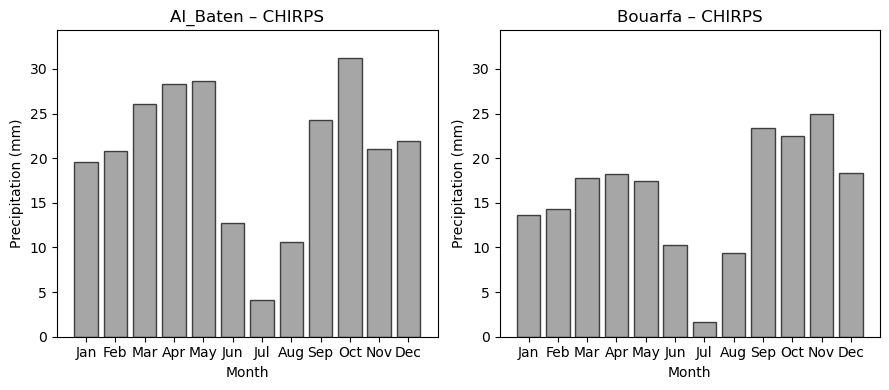

In [240]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. Load & filter TerraClimate
# =====================================================
clim_areas = pd.read_csv("Climate_AB_Monthly_2000_2025.csv")
clim_areas["date"] = pd.to_datetime(clim_areas["date"])
clim_areas["month"] = clim_areas["date"].dt.month

ch = clim_areas[clim_areas["dataset"] == "CHIRPS"].copy()

print(ch.shape)
print(ch["dataset"].unique())
print(ch["precip_mm"].isna().sum())
print(ch.head())
# =====================================================
# 2. Long-term monthly climatology
# =====================================================
monthly_clim = (
    ch.groupby(["region", "month"])
      .agg(
          # temp_C=("temp2m_C", "mean"),
          precip_mm=("precip_mm", "mean")
      )
      .reset_index()
)
print(monthly_clim.head())
# =====================================================
# 3. Determine common y-axis limit for precipitation
# =====================================================
precip_max = monthly_clim["precip_mm"].max() * 1.1  # 10% padding
# print(precip_max)
print(f"Max Precipitation: {precip_max:.3f}")
# =====================================================
# 4. Plot dual-axis climatology (black-white)
# =====================================================
regions = monthly_clim["region"].unique()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(nrows=1, ncols=len(regions), figsize=(9, 4), sharey=False)
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    df = monthly_clim[monthly_clim["region"] == region]

    # --- Precipitation (bars) ---
    ax.bar(
        df["month"],
        df["precip_mm"],
        color='gray',
        edgecolor='black',
        alpha=0.7
    )
    ax.set_ylabel("Precipitation (mm)")
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_title(f"{region} – CHIRPS")
    ax.set_ylim(0, precip_max)  # same y-axis for comparison

    # # --- Temperature (line, right axis) ---
    # ax2 = ax.twinx()
    # ax2.plot(
    #     df["month"],
    #     df["temp_C"],
    #     color='black',
    #     marker='o',
    #     linewidth=2
    # )
    # ax2.set_ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()


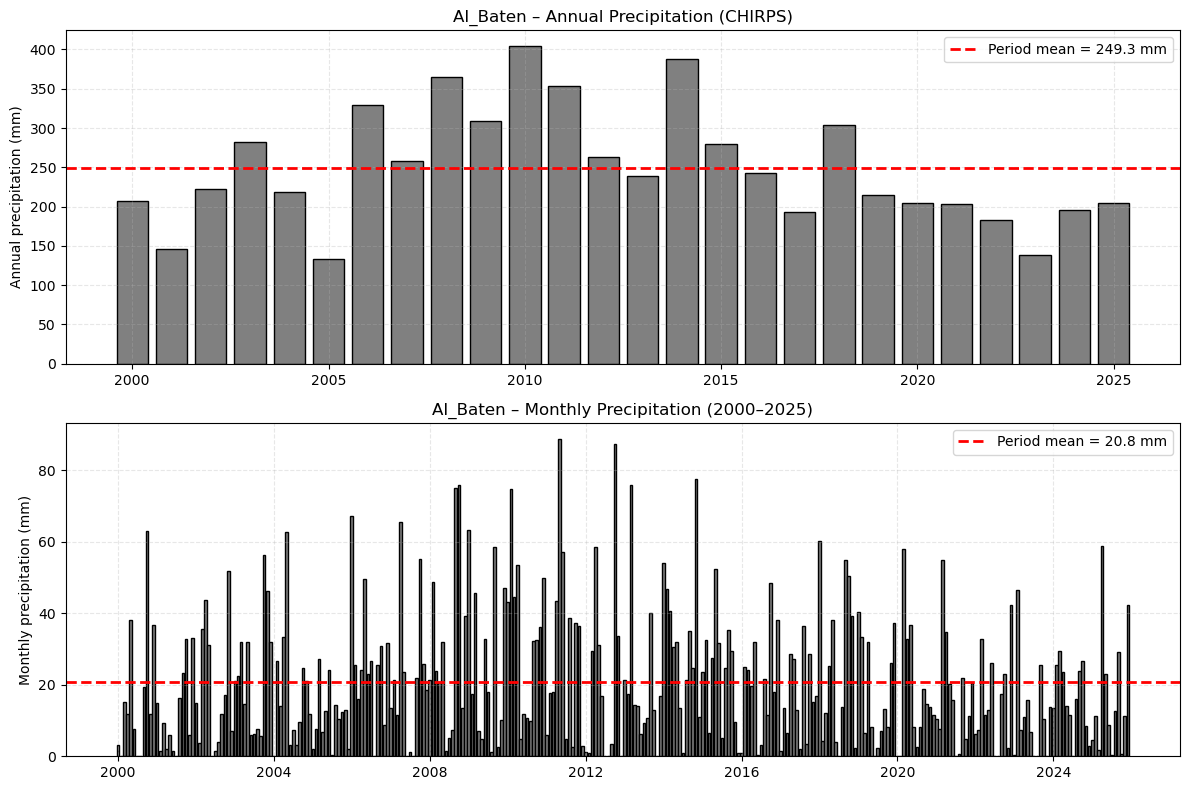

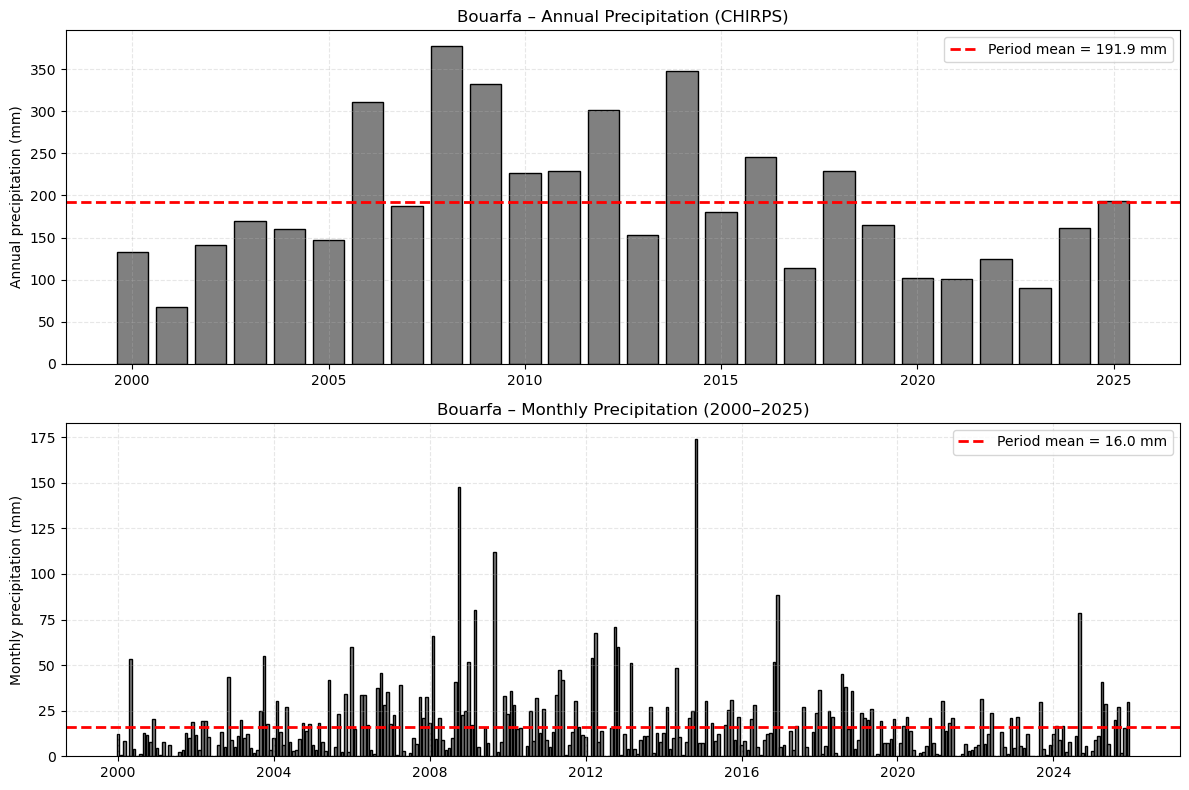

In [236]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. Load & filter CHIRPS
# =====================================================
clim_areas = pd.read_csv("Climate_AB_Monthly_2000_2025.csv")
clim_areas["date"] = pd.to_datetime(clim_areas["date"])
clim_areas["year"] = clim_areas["date"].dt.year
clim_areas["month"] = clim_areas["date"].dt.month

ch = clim_areas[clim_areas["dataset"] == "CHIRPS"].copy()
ch = ch.dropna(subset=["precip_mm"])

if ch.empty:
    raise ValueError("No CHIRPS data found.")

# =====================================================
# 2. Loop through regions
# =====================================================
regions = ch["region"].unique()

for region in regions:

    df = ch[ch["region"] == region].copy()

    # -----------------------------
    # Annual totals
    # -----------------------------
    annual = (
        df.groupby("year")["precip_mm"]
          .sum()
          .reset_index()
    )

    period_mean_annual = annual["precip_mm"].mean()

    # -----------------------------
    # Monthly series
    # -----------------------------
    monthly = df.sort_values("date")

    period_mean_monthly = monthly["precip_mm"].mean()

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # =============================
    # Panel 1: Annual precipitation
    # =============================
    ax1 = axes[0]

    ax1.bar(
        annual["year"],
        annual["precip_mm"],
        color="gray",
        edgecolor="black"
    )

    ax1.axhline(
        period_mean_annual,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Period mean = {period_mean_annual:.1f} mm"
    )

    ax1.set_ylabel("Annual precipitation (mm)")
    ax1.set_title(f"{region} – Annual Precipitation (CHIRPS)")
    ax1.legend()
    ax1.grid(alpha=0.3, linestyle="--")

    # =============================
    # Panel 2: Monthly time series
    # =============================
    ax2 = axes[1]

    ax2.bar(
        monthly["date"],
        monthly["precip_mm"],
        width=25,
        color="gray",
        edgecolor="black"
    )

    ax2.axhline(
        period_mean_monthly,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Period mean = {period_mean_monthly:.1f} mm"
    )

    ax2.set_ylabel("Monthly precipitation (mm)")
    ax2.set_title(f"{region} – Monthly Precipitation (2000–2025)")
    ax2.legend()
    ax2.grid(alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()


# GEE Random Forest Classification (2nd Edition)

In [11]:
import ee
import pandas as pd
import geemap
import matplotlib.pyplot as plt

# Trigger the authentication flow.
# ee.Authenticate()

# Initialize the library.
ee.Initialize(project='rse-global-wetlands') # this is the esential step!

Enter verification code:  4/1Aci98E89P4QxFxs81qqgmwrLuRzcHxT3mimWqbuDqwpikfv9n3Rds-Tqh1E



Successfully saved authorization token.


In [1]:
# Updates on 3/18
# 1.updated the habitat classes names, used the noramlized version edited on 3/9
# 2.updated the linear habitats for wadi and gullies, 24 plots in Bouarfa
# 3.combined the supplymantory ground materials: polyways(roads,railway and waterway) & build-up areas
# there mateirals have been uploaded to GEE
# 'Phy_Bouarfa_train.shp' to 'Phy_Bouarfa_train_318'
# 'Waterbody_Bouarfa_buffer.shp' to 'Waterbody_Bouarfa'
# 'Polyway_Bouarfa_buffer.shp' to 'Polyway_Bouarfa'
# 'Build-up_buarfa.shp' to 'Build-up_Buarfa'

In [17]:
# =========================================================
# PARAMETERS:Updated on 3/18
# =========================================================
PARAMS = {
    "study_area_asset": "projects/rse-global-wetlands/assets/Bouarfa_study_area",
    "study_area_asset_EM": "projects/rse-global-wetlands/assets/mgrs_NW_grid_EM_boundary",
    "training_asset": "projects/rse-global-wetlands/assets/Phy_Bouarfa_train_318", #THIS IS THE UPDATED TRAINING DATASETS FROM PHY SURVEY
    # "training_asset_EM":"projects/rse-global-wetlands/assets/Phy_EaternMorocco_train" #Need to modify later
    # "waterway": "projects/rse-global-wetlands/assets/OSM_AF_Waterways_Bouarfa",
    # replaced by polyway
    "polyway": "projects/rse-global-wetlands/assets/Polyway_Bouarfa", #266
    "water_body": "projects/rse-global-wetlands/assets/Waterbody_Bouarfa", #148
    # replaced by Build-up, combined the below two files
    "build-up":"projects/rse-global-wetlands/assets/Build-up_Buarfa", #83
    # "populated_places":"projects/rse-global-wetlands/assets/hotosm_mar_populated_places_polygons_bouarfa",
    # "building":"projects/rse-global-wetlands/assets/hotosm_mar_buildings_polygons_bouarfa",
    "anthropized_land":"projects/rse-global-wetlands/assets/Bouarfa_anthropized_land", #think about how to use this dataset

    "classification_start": "2025-03-01",
    "classification_end": "2025-03-31",

    "water_start": "2024-09-01",
    "water_end": "2024-09-30",

    "cloud_threshold": 10,
    "ndwi_threshold": 0.2, # need to be tested;water body is impossible to remove
    "ndvi_threshold": 0.2,

    "use_dem": True,
    "use_water_mask": True,
    "use_anthro_mask": False,

    "n_trees": 500,

    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ]
}

CLASS_DICT = {
    'Non-floodable steppe': 0,
    'Alfah-grass steppe': 1,
    'Chamaephytes steppe': 2,
    'Salty steppe': 3,
    'Dune': 4,
    'Daya': 5,
    'Wadi and gullies': 6,
    'Cultivated field/fallow': 7,
    'Build-up': 8,
    'Road': 9,
    'Water body': 10
}

### WATER MASK ISSUES

In [10]:
# the pre-step is to pre-analysis the water-boundary: using the composite image in 2024 september, using the NDWI
# 1.see the NDWI values distribution, and set the proper theroshold

# Build Sentinel-2 composite (Sept 2024)
study_area = ee.FeatureCollection(PARAMS["study_area_asset"])
def mask_s2(image):
    qa = image.select('QA60')
    cloud = qa.bitwiseAnd(1 << 10).eq(0)
    cirrus = qa.bitwiseAnd(1 << 11).eq(0)
    return image.updateMask(cloud.And(cirrus))

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(study_area)
    .filterDate(PARAMS["water_start"], PARAMS["water_end"])
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', PARAMS["cloud_threshold"]))
    .map(mask_s2)
)
# Median composite
composite = s2.median().clip(study_area)

# Compute NDWI and NDVI(as a reference)
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

In [11]:
# Get NDWI histogram
hist_dict = ndwi.reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=100),
    geometry=study_area,
    scale=10,
    bestEffort=True
)

hist = hist_dict.getInfo()['NDWI']

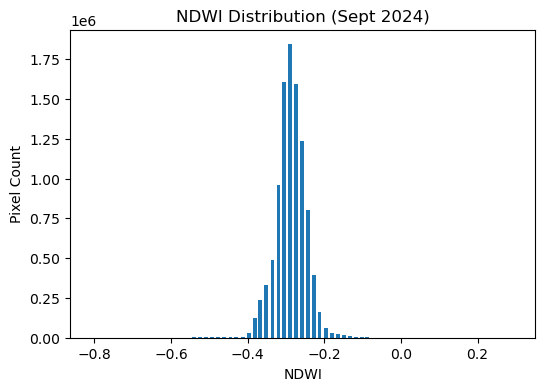

In [12]:
# Plot NDWI distribution: Extract histogram
bucket_means = hist['bucketMeans']
counts = hist['histogram']

plt.figure(figsize=(6,4))
plt.bar(bucket_means, counts, width=0.01)
plt.xlabel("NDWI")
plt.ylabel("Pixel Count")
plt.title("NDWI Distribution (Sept 2024)")
plt.show()

In [15]:
# Test NDWI thresholds
Map = geemap.Map()
Map.centerObject(study_area, 10)

Map.addLayer(ndwi, {"min": -0.5, "max": 0.5, "palette": ['brown','white','blue']}, "NDWI")

thresholds = [-0.4, -0.3, -0.2, -0.1, 0, 0.05]

for th in thresholds:
    water_mask = ndwi.gt(th)
    Map.addLayer(
        water_mask.updateMask(water_mask),
        {"palette": ["blue"]},
        f"Water NDWI > {th}"
    )

Map

Map(center=[32.40028180984951, -2.3354295416373265], controls=(WidgetControl(options=['position', 'transparent…

In [16]:
# Add reference water layer
waterbody = ee.FeatureCollection(PARAMS["water_body"])
Map.addLayer(polyway, {"color": "cyan"}, "Reference Water")

### Modifications

In [ ]:
# Use shorter temporal windows Instead of monthly:1-2 week windows
# or Find weeks(9/8&9/11)with max precipitation then Shift NDWI window by +1–3 weeks (9/15-10/7)
# .filterDate("2024-09-15", "2024-10-07")
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(study_area)
    .filterDate("2024-08-15", "2024-10-15")
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', PARAMS["cloud_threshold"]))
    .map(mask_s2)
)

# Switch from median --> max NDWI, Capture any water occurrence
composite = s2.max().clip(study_area)

# Compute NDWI and NDVI(as a reference)
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

# in addition try MNDWI
mndwi = composite.normalizedDifference(['B3','B11']).rename('mNDWI')


In [ ]:
# Get NDWI histogram
hist_dict1 = ndwi.reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=100),
    geometry=study_area,
    scale=10,
    bestEffort=True
)

hist1 = hist_dict1.getInfo()['NDWI']

hist_dict2 = mndwi.reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=100),
    geometry=study_area,
    scale=10,
    bestEffort=True
)

hist2 = hist_dict2.getInfo()['mNDWI']

In [ ]:
import matplotlib.pyplot as plt

# Extract values
x1 = hist1['bucketMeans']
y1 = hist1['histogram']

x2 = hist2['bucketMeans']
y2 = hist2['histogram']

plt.figure(figsize=(7,5))

plt.plot(x1, y1, label="NDWI")
plt.plot(x2, y2, label="MNDWI")

plt.xlabel("Index Value")
plt.ylabel("Pixel Count")
plt.title("NDWI vs MNDWI Distribution(9/15-10/5/2024)")
plt.legend()

plt.show()

In [ ]:
import numpy as np

y1_norm = np.array(y1) / np.sum(y1)
y2_norm = np.array(y2) / np.sum(y2)

plt.figure(figsize=(7,5))

plt.plot(x1, y1_norm, label="NDWI")
plt.plot(x2, y2_norm, label="MNDWI")

plt.xlabel("Index Value")
plt.ylabel("Probability Density")
plt.title("Normalized NDWI vs MNDWI Distribution")
plt.legend()

plt.show()

In [ ]:
common_bins = np.linspace(-1, 1, 100)

# Interpolate
y1_interp = np.interp(common_bins, x1, y1)
y2_interp = np.interp(common_bins, x2, y2)

plt.figure(figsize=(7,5))
plt.plot(common_bins, y1_interp, label="NDWI")
plt.plot(common_bins, y2_interp, label="MNDWI")

plt.legend()
plt.xlabel("Index Value")
plt.ylabel("Pixel Count")
plt.title("Re-binned Comparison")

plt.show()

### Modifications
- two things: (1) Water response ≠ instantaneous, so even though Sept 2024 had more rainfall but image didn't get the information; typical 1-4 weeks laf
- (2)Median composite removes extremes

In [17]:
# Use shorter temporal windows Instead of monthly:1-2 week windows
# or Find weeks(9/8&9/11)with max precipitation then Shift NDWI window by +1–3 weeks (9/15-10/7)
# .filterDate("2024-09-15", "2024-10-07")
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(study_area)
    .filterDate("2024-08-15", "2024-10-15")
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', PARAMS["cloud_threshold"]))
    .map(mask_s2)
)

# Switch from median --> max NDWI, Capture any water occurrence
composite = s2.max().clip(study_area)

# Compute NDWI and NDVI(as a reference)
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

# in addition try MNDWI
mndwi = composite.normalizedDifference(['B3','B11']).rename('mNDWI')


In [21]:
# Get NDWI histogram
hist_dict1 = ndwi.reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=100),
    geometry=study_area,
    scale=10,
    bestEffort=True
)

hist1 = hist_dict1.getInfo()['NDWI']

hist_dict2 = mndwi.reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=100),
    geometry=study_area,
    scale=10,
    bestEffort=True
)

hist2 = hist_dict2.getInfo()['mNDWI']

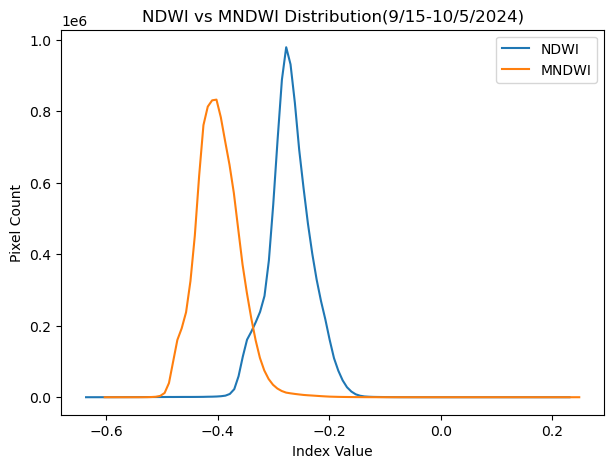

In [25]:
import matplotlib.pyplot as plt

# Extract values
x1 = hist1['bucketMeans']
y1 = hist1['histogram']

x2 = hist2['bucketMeans']
y2 = hist2['histogram']

plt.figure(figsize=(7,5))

plt.plot(x1, y1, label="NDWI")
plt.plot(x2, y2, label="MNDWI")

plt.xlabel("Index Value")
plt.ylabel("Pixel Count")
plt.title("NDWI vs MNDWI Distribution(9/15-10/5/2024)")
plt.legend()

plt.show()

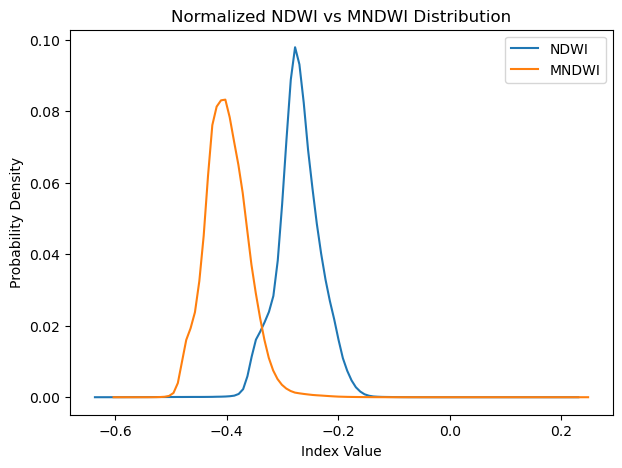

In [23]:
import numpy as np

y1_norm = np.array(y1) / np.sum(y1)
y2_norm = np.array(y2) / np.sum(y2)

plt.figure(figsize=(7,5))

plt.plot(x1, y1_norm, label="NDWI")
plt.plot(x2, y2_norm, label="MNDWI")

plt.xlabel("Index Value")
plt.ylabel("Probability Density")
plt.title("Normalized NDWI vs MNDWI Distribution")
plt.legend()

plt.show()

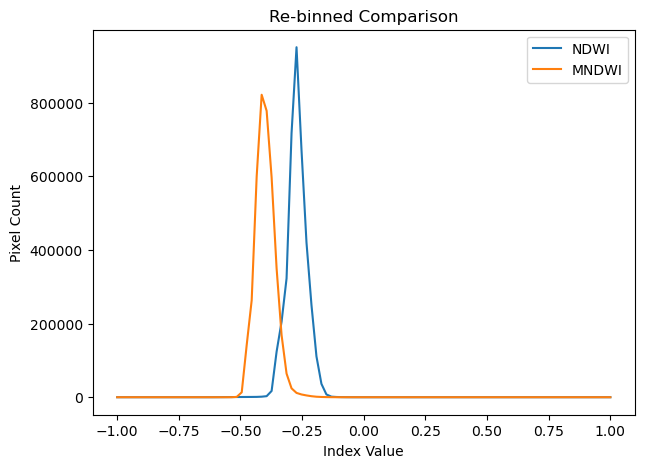

In [24]:
common_bins = np.linspace(-1, 1, 100)

# Interpolate
y1_interp = np.interp(common_bins, x1, y1)
y2_interp = np.interp(common_bins, x2, y2)

plt.figure(figsize=(7,5))
plt.plot(common_bins, y1_interp, label="NDWI")
plt.plot(common_bins, y2_interp, label="MNDWI")

plt.legend()
plt.xlabel("Index Value")
plt.ylabel("Pixel Count")
plt.title("Re-binned Comparison")

plt.show()

## Classification try
- comments: design a multi-temporal feature stack (very impactful for these habitats)

In [68]:
import ee
import geemap

ee.Initialize(project='rse-global-wetlands') # this is the esential step!

# =========================================================
# PARAMETERS
# =========================================================
PARAMS = {
    "study_area_asset": "projects/rse-global-wetlands/assets/Bouarfa_study_area",
    "training_asset": "projects/rse-global-wetlands/assets/Phy_Bouarfa_train_318", #202
    "polyway": "projects/rse-global-wetlands/assets/Polyway_Bouarfa", #266
    "water_body": "projects/rse-global-wetlands/assets/Waterbody_Bouarfa", #148
    "build-up":"projects/rse-global-wetlands/assets/Build-up_Bouarfa", #83
    
    "classification_start": "2025-03-01",
    "classification_end": "2025-03-31",

    "cloud_threshold": 10,
    "n_trees": 500,

    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ]
}

# =========================================================
# CLASS DICTIONARY
# =========================================================
CLASS_DICT = {
    'Non-floodable steppe': 0,
    'Alfah-grass steppe': 1,
    'Chamaephytes steppe': 2,
    'Salty steppe': 3,
    'Dune': 4,
    'Daya': 5,
    'Wadi and gullies': 6,
    'Cultivated field/fallow': 7,
    'Build-up': 8,
    'Road': 9,
    'Water body': 10
}

# =========================================================
# LOAD ASSETS
# =========================================================
def load_assets(params):
    study_area = ee.FeatureCollection(params["study_area_asset"])
    training_fc = ee.FeatureCollection(params["training_asset"])
    return study_area, training_fc

def load_training_data(params):
    base = ee.FeatureCollection(params["training_asset"])
    built = ee.FeatureCollection(params["build-up"]).map(lambda f: f.set('class_id', 8))
    road  = ee.FeatureCollection(params["polyway"]).map(lambda f: f.set('class_id', 9))
    water = ee.FeatureCollection(params["water_body"]).map(lambda f: f.set('class_id', 10))
    merged = base.merge(water).merge(road).merge(built)
    return merged
    
# =========================================================
# ENCODE CLASSES
# =========================================================
def encode_classes(training_fc):
    class_dict = ee.Dictionary(CLASS_DICT)

    def map_fn(f):
        class_id = class_dict.get(f.get('Habitat_2_'))
        return f.set('class_id', class_id)

    return training_fc.map(map_fn).filter(ee.Filter.notNull(['class_id']))

# =========================================================
# SENTINEL-2 PREPROCESSING
# =========================================================
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit = 1 << 10
    cirrus_bit = 1 << 11

    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(
        qa.bitwiseAnd(cirrus_bit).eq(0)
    )

    return image.updateMask(mask).divide(10000)

def load_sentinel(start, end, study_area, cloud_thresh):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(study_area)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
        .map(mask_s2_clouds)
        .median()
        .clip(study_area)
    )

# =========================================================
# INDICES
# =========================================================
def add_indices(image):

    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndmi = image.normalizedDifference(['B8', 'B11']).rename('NDMI')
    # Water
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    nbr  = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    # Built-up
    ndbi = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    # Road / bare surfaces
    bsi = image.expression(
    '((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))',
    {
        'SWIR': image.select('B11'),
        'RED': image.select('B4'),
        'NIR': image.select('B8'),
        'BLUE': image.select('B2')
    }).rename('BSI')
    
    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5',
        {'NIR': image.select('B8'), 'RED': image.select('B4')}
    ).rename('SAVI')

    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {'NIR': image.select('B8'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('EVI')

    msavi = image.expression(
        '(2*NIR + 1 - sqrt((2*NIR + 1)**2 - 8*(NIR - RED))) / 2',
        {'NIR': image.select('B8'), 'RED': image.select('B4')}
    ).rename('MSAVI')

    # return image.addBands([ndvi, ndmi, nbr, savi, evi, msavi])
    return image.addBands([ndvi, ndmi, nbr, savi, evi, msavi, mndwi, ndbi, bsi])

# =========================================================
# FEATURE STACK
# =========================================================
def build_feature_stack(params):

    # study_area, training_fc = load_assets(params)
    
    study_area = ee.FeatureCollection(params["study_area_asset"])
    training_fc = load_training_data(params)

    image = load_sentinel(
        params["classification_start"],
        params["classification_end"],
        study_area,
        params["cloud_threshold"]
    )

    image = add_indices(image)

    return image, training_fc, study_area

# =========================================================
# SAMPLING: Random vs. Stratified
# =========================================================
# random sampling
def sample_data(image, training_fc, params):

    predictors = params["predictor_bands"]

    samples = image.select(predictors).sampleRegions(
        collection=training_fc,
        properties=['class_id'],
        scale=10,
        geometries=False
    )

    # remove null pixels
    samples = samples.filter(ee.Filter.notNull(predictors))

    samples = samples.randomColumn('random')

    train = samples.filter(ee.Filter.lt('random', 0.7))
    test  = samples.filter(ee.Filter.gte('random', 0.7))

    print("Total samples:", samples.size().getInfo())
    print("Train samples:", train.size().getInfo())
    print("Test samples:", test.size().getInfo())

    return train, test

# stratified sampling
def stratified_sample(image, training_fc, params):

    predictors = params["predictor_bands"]

    samples = image.select(predictors).sampleRegions(
        collection=training_fc,
        properties=['class_id'],
        scale=10,
        geometries=False
    )

    samples = samples.filter(ee.Filter.notNull(predictors))

    # balance classes
    samples = samples.stratifiedSample(
        numPoints=500,
        classBand='class_id',
        region=training_fc.geometry(),
        scale=10,
        geometries=False
    )

    samples = samples.randomColumn('random')

    train = samples.filter(ee.Filter.lt('random', 0.7))
    test  = samples.filter(ee.Filter.gte('random', 0.7))

    return train, test
    
# =========================================================
# TRAIN RF
# =========================================================
def train_rf(train_set, params):

    classifier = ee.Classifier.smileRandomForest(
        numberOfTrees=params["n_trees"]
    ).train(
        features=train_set,
        classProperty='class_id',
        inputProperties=params["predictor_bands"]
    )

    return classifier

# =========================================================
# ACCURACY
# =========================================================
def assess_accuracy(classifier, test_set):

    validation = test_set.classify(classifier)
    cm = validation.errorMatrix('class_id', 'classification')

    print("\nConfusion Matrix:\n", cm.getInfo())
    print("\nOverall Accuracy:", cm.accuracy().getInfo())
    print("Kappa:", cm.kappa().getInfo())

    return cm

# =========================================================
# CLASSIFY
# =========================================================
def classify_image(image, classifier, params):
    return image.select(params["predictor_bands"]).classify(classifier)

# =========================================================
# RUN PIPELINE
# =========================================================
def run_experiment(params):

    image, training_fc, study_area = build_feature_stack(params)

    training_fc = encode_classes(training_fc)

    # Debug: class distribution
    print("Class distribution:",
          training_fc.aggregate_histogram('class_id').getInfo())

    # train, test = sample_data(image, training_fc, params)
    train, test = stratified_sample(image, training_fc, params)
    
    classifier = train_rf(train, params)

    # importance = classifier.explain().get('importance')
    # print("Feature importance:", importance.getInfo())

    assess_accuracy(classifier, test)

    classified = classify_image(image, classifier, params)

    return classified, classifier, study_area, training_fc

# # =========================================================
# # RUN
# # =========================================================
# classified, classifier, study_area, training_fc = run_experiment(PARAMS)

# # =========================================================
# # VISUALIZATION
# # =========================================================
# Map = geemap.Map()
# Map.centerObject(study_area, 11)

# palette = [
#     '#FFFF00','#00FF00','#228B22','#8B4513','#FFD700',
#     '#00FFFF','#808080','#FF0000','#000000','#FFA500','#0000FF'
# ]

# Map.addLayer(classified, {'min':0, 'max':10, 'palette': palette}, 'Classification')
# Map.addLayer(training_fc.style(color='black', fillColor='00000000'), {}, 'Training')

# Map

In [69]:
# AI Baten

import ee
import geemap

ee.Initialize(project='rse-global-wetlands') 

# =========================================================
# PARAMETERS
# =========================================================
PARAMS = {
    "study_area_asset": "projects/rse-global-wetlands/assets/Al_Baten_study_area",
    "training_asset": "projects/rse-global-wetlands/assets/AI_Baten_rdpoints_300mbuf_train_326",
    
    "classification_start": "2025-03-01",
    "classification_end": "2025-03-31",

    "cloud_threshold": 10,
    "n_trees": 500,

    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ]
}

# # =========================================================
# # CLASS DICTIONARY
# # =========================================================
# CLASS_DICT = {
#     'Non-floodable steppe': 0,
#     'Alfah-grass steppe': 1,
#     'Chamaephytes steppe': 2,
#     'Salty steppe': 3,
#     'Dune': 4,
#     'Daya': 5,
#     'Wadi and gullies': 6,
#     'Cultivated field/fallow': 7,
#     'Build-up': 8,
#     'Road': 9,
#     'Water body': 10
# }

# CLASS_DICT = {
#     'Alfah-grass steppe': 0,
#     'Spreading area': 1,
#     'Reg': 2,
#     'Salty steppe': 3,
#     'Wadi and gullies': 4,
#     'Cultivated field/fallow': 5,
#     'Build-up': 6
# }

# =========================================================
# LOAD ASSETS
# =========================================================
def load_assets(params):
    study_area = ee.FeatureCollection(params["study_area_asset"])
    training_fc = ee.FeatureCollection(params["training_asset"])
    return study_area, training_fc

def load_training_data(params):
    base = ee.FeatureCollection(params["training_asset"])
    built = ee.FeatureCollection(params["build-up"]).map(lambda f: f.set('class_id', 8))
    road  = ee.FeatureCollection(params["polyway"]).map(lambda f: f.set('class_id', 9))
    water = ee.FeatureCollection(params["water_body"]).map(lambda f: f.set('class_id', 10))
    merged = base.merge(water).merge(road).merge(built)
    return merged
    
# =========================================================
# ENCODE CLASSES
# =========================================================
def encode_classes(training_fc):
    class_dict = ee.Dictionary(CLASS_DICT)

    def map_fn(f):
        class_id = class_dict.get(f.get('Habitat'))
        return f.set('class_id', class_id)

    return training_fc.map(map_fn).filter(ee.Filter.notNull(['class_id']))

# =========================================================
# SENTINEL-2 PREPROCESSING
# =========================================================
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit = 1 << 10
    cirrus_bit = 1 << 11

    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(
        qa.bitwiseAnd(cirrus_bit).eq(0)
    )

    return image.updateMask(mask).divide(10000)

def load_sentinel(start, end, study_area, cloud_thresh):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(study_area)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
        .map(mask_s2_clouds)
        .median()
        .clip(study_area)
    )

# =========================================================
# INDICES
# =========================================================
def add_indices(image):

    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndmi = image.normalizedDifference(['B8', 'B11']).rename('NDMI')
    # Water
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    nbr  = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    # Built-up
    ndbi = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    # Road / bare surfaces
    bsi = image.expression(
    '((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))',
    {
        'SWIR': image.select('B11'),
        'RED': image.select('B4'),
        'NIR': image.select('B8'),
        'BLUE': image.select('B2')
    }).rename('BSI')
    
    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5',
        {'NIR': image.select('B8'), 'RED': image.select('B4')}
    ).rename('SAVI')

    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {'NIR': image.select('B8'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('EVI')

    msavi = image.expression(
        '(2*NIR + 1 - sqrt((2*NIR + 1)**2 - 8*(NIR - RED))) / 2',
        {'NIR': image.select('B8'), 'RED': image.select('B4')}
    ).rename('MSAVI')

    # return image.addBands([ndvi, ndmi, nbr, savi, evi, msavi])
    return image.addBands([ndvi, ndmi, nbr, savi, evi, msavi, mndwi, ndbi, bsi]).toFloat()

# =========================================================
# FEATURE STACK
# =========================================================
def build_feature_stack(params):

    study_area, training_fc = load_assets(params)
    
    # study_area = ee.FeatureCollection(params["study_area_asset"])
    # training_fc = load_training_data(params)

    image = load_sentinel(
        params["classification_start"],
        params["classification_end"],
        study_area,
        params["cloud_threshold"]
    )

    image = add_indices(image)

    return image, training_fc, study_area

# =========================================================
# SAMPLING: Random vs. Stratified
# =========================================================
# random sampling
def sample_data(image, training_fc, params):

    predictors = params["predictor_bands"]

    samples = image.select(predictors).sampleRegions(
        collection=training_fc,
        properties=['class_id'],
        scale=10,
        geometries=False
    )

    # remove null pixels
    samples = samples.filter(ee.Filter.notNull(predictors))

    samples = samples.randomColumn('random')

    train = samples.filter(ee.Filter.lt('random', 0.7))
    test  = samples.filter(ee.Filter.gte('random', 0.7))

    print("Total samples:", samples.size().getInfo())
    print("Train samples:", train.size().getInfo())
    print("Test samples:", test.size().getInfo())

    return train, test

# stratified sampling
def stratified_sample(image, training_fc, params):

    predictors = params["predictor_bands"]

    samples = image.select(predictors).sampleRegions(
        collection=training_fc,
        properties=['class_id'],
        scale=10,
        geometries=False
    )

    samples = samples.filter(ee.Filter.notNull(predictors))

    # balance classes
    samples = samples.stratifiedSample(
        numPoints=500,
        classBand='class_id',
        region=training_fc.geometry(),
        scale=10,
        geometries=False
    )

    samples = samples.randomColumn('random')

    train = samples.filter(ee.Filter.lt('random', 0.7))
    test  = samples.filter(ee.Filter.gte('random', 0.7))

    return train, test
    
# =========================================================
# TRAIN RF
# =========================================================
def train_rf(train_set, params):

    classifier = ee.Classifier.smileRandomForest(
        numberOfTrees=params["n_trees"]
    ).train(
        features=train_set,
        classProperty='class_id',
        inputProperties=params["predictor_bands"]
    )

    return classifier

# =========================================================
# ACCURACY
# =========================================================
def assess_accuracy(classifier, test_set):

    validation = test_set.classify(classifier)
    cm = validation.errorMatrix('class_id', 'classification')

    print("\nConfusion Matrix:\n", cm.getInfo())
    print("\nOverall Accuracy:", cm.accuracy().getInfo())
    print("Kappa:", cm.kappa().getInfo())

    return cm

# =========================================================
# CLASSIFY
# =========================================================
def classify_image(image, classifier, params):
    return image.select(params["predictor_bands"]).classify(classifier)

# =========================================================
# RUN PIPELINE
# =========================================================
def run_experiment(params):

    image, training_fc, study_area = build_feature_stack(params)

    training_fc = encode_classes(training_fc)

    # Debug: class distribution
    print("Class distribution:",
          training_fc.aggregate_histogram('class_id').getInfo())

    train, test = sample_data(image, training_fc, params)

    classifier = train_rf(train, params)

    # importance = classifier.explain().get('importance')
    # print("Feature importance:", importance.getInfo())

    assess_accuracy(classifier, test)

    classified = classify_image(image, classifier, params)

    return classified, classifier, study_area, training_fc

In [ ]:
# =========================================================
# RUN
# =========================================================
classified, classifier, study_area, training_fc = run_experiment(PARAMS)

# =========================================================
# VISUALIZATION
# =========================================================
Map = geemap.Map()
Map.centerObject(study_area, 11)

palette = [
    '#FFFF00','#00FF00','#228B22','#8B4513','#FFD700',
    '#00FFFF','#808080','#FF0000','#000000','#FFA500','#0000FF'
]

Map.addLayer(classified, {'min':0, 'max':10, 'palette': palette}, 'Classification')
Map.addLayer(training_fc.style(color='black', fillColor='00000000'), {}, 'Training')

Map

In [15]:
import pandas as pd
import numpy as np

# Confusion matrix
cm = np.array( [[628, 0, 5, 3, 2, 0, 10, 17], 
                [2, 15, 1, 0, 0, 0, 8, 0], 
                [21, 1, 148, 0, 0, 0, 15, 6], 
                [5, 0, 1, 12, 0, 0, 0, 1], 
                [11, 0, 3, 0, 65, 0, 3, 0], 
                [2, 1, 0, 1, 0, 2, 0, 0], 
                [41, 1, 12, 1, 1, 0, 203, 4], 
                [27, 0, 0, 1, 3, 0, 2, 89]])

# Class names corresponding to CLASS_DICT order
# {'0': 94, '1': 4, '2': 36, '3': 5, '4': 16, '5': 4, '6': 27, '7': 24}
class_names = [
    "Non-floodable steppe",
    "Alfah-grass steppe",
    "Chamaephytes steppe",
    "Salty steppe",
    "Dune",
    "Daya",
    "Wadi and gullies",
    "Cultivated field/fallow"
]

# Create a DataFrame
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Save to CSV
cm_df.to_csv("confusion_matrix_0325.csv")

# Optionally, save to Excel
# cm_df.to_excel("confusion_matrix.xlsx")

print(cm_df)

                         Non-floodable steppe  Alfah-grass steppe  \
Non-floodable steppe                      628                   0   
Alfah-grass steppe                          2                  15   
Chamaephytes steppe                        21                   1   
Salty steppe                                5                   0   
Dune                                       11                   0   
Daya                                        2                   1   
Wadi and gullies                           41                   1   
Cultivated field/fallow                    27                   0   

                         Chamaephytes steppe  Salty steppe  Dune  Daya  \
Non-floodable steppe                       5             3     2     0   
Alfah-grass steppe                         1             0     0     0   
Chamaephytes steppe                      148             0     0     0   
Salty steppe                               1            12     0     0   
Dune    

In [16]:
# Export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=classified,
    description='Habitat2_Classification_March2025',
    folder='GEE_exports',
    fileNamePrefix='Bouarfa_Habitat_2_',
    scale=10,
    region=study_area.geometry(),
    crs='EPSG:4326',
    maxPixels=1e13
)
task.start()
print("Export started, check GEE Tasks tab.")


Export started, check GEE Tasks tab.


## Download the S2 composite image

In [56]:
def export_s2_composite(PARAMS, image, study_area):
    description = f"{PARAMS['study_area_name']}_S2_{PARAMS['classification_start']}_{PARAMS['classification_end']}"
    filename = description
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder='GEE_exports',
        fileNamePrefix=filename,
        region=study_area.geometry(),
        scale=10,
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    print("Export started...")

def export_training_samples(image, training_fc, params, description = 'Bouarfa_training_samples'): 
    samples = image.select(params["predictor_bands"]).sampleRegions(
        collection=training_fc,
        properties=['class_id', 'Habitat'],
        scale=10,
        geometries=True
    )

    task = ee.batch.Export.table.toDrive(
        collection=samples,
        description=description,
        fileFormat='CSV'
    )

    task.start()
    print("Training export started...")

In [55]:
PARAMS = {
    "study_area_name": 'AI_Baten',
    "study_area_asset": "projects/rse-global-wetlands/assets/Al_Baten_study_area",
    "training_asset": "projects/rse-global-wetlands/assets/AI_Baten_rdpoints_300mbuf_train_326",
    
    "classification_start": "2025-03-01",
    "classification_end": "2025-03-31",

    "cloud_threshold": 10,
    "n_trees": 500,

    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ]
}

CLASS_DICT = {
    'Alfah-grass steppe': 0,
    'Spreading area': 1,
    'Reg': 2,
    'Salty steppe': 3,
    'Wadi and gullies': 4,
    'Cultivated field/fallow': 5,
    'Build-up': 6
}

image, training_fc, study_area = build_feature_stack(PARAMS)
training_fc = encode_classes(training_fc)

In [ ]:
export_s2_composite(PARAMS,image,study_area)

In [57]:
export_training_samples(image, training_fc, PARAMS, description = 'AI_Baten_training_samples')

Training export started...


In [79]:
PARAMS = {
    "study_area_name": 'Bouarfa',
    "study_area_asset": "projects/rse-global-wetlands/assets/Bouarfa_study_area",
    "training_asset": "projects/rse-global-wetlands/assets/Phy_Bouarfa_train_318", #202
    "polyway": "projects/rse-global-wetlands/assets/Polyway_Bouarfa", #266
    "water_body": "projects/rse-global-wetlands/assets/Waterbody_Bouarfa", #148
    "build-up":"projects/rse-global-wetlands/assets/Build-up_Bouarfa", #83
    
    "classification_start": "2025-03-01",
    "classification_end": "2025-03-31",

    "cloud_threshold": 10,
    "n_trees": 500,

    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ]
}

def export_training_samples(image, training_fc, params, description = 'Bouarfa_training_samples'): 
    samples = image.select(params["predictor_bands"]).sampleRegions(
        collection=training_fc,
        properties=['class_id', 'Habitat_2_'],
        scale=10,
        geometries=True
    )

    task = ee.batch.Export.table.toDrive(
        collection=samples,
        description=description,
        fileFormat='CSV'
    )

    task.start()
    print("Training export started...")

def encode_classes(training_fc):
    class_dict = ee.Dictionary(CLASS_DICT)

    def map_fn(f):
        class_id = class_dict.get(f.get('Habitat_2_'))
        return f.set('class_id', class_id)

    return training_fc.map(map_fn).filter(ee.Filter.notNull(['class_id']))
    
def build_feature_stack(params):

    # study_area, training_fc = load_assets(params)
    
    study_area = ee.FeatureCollection(params["study_area_asset"])
    training_fc = load_training_data(params)

    image = load_sentinel(
        params["classification_start"],
        params["classification_end"],
        study_area,
        params["cloud_threshold"]
    )

    image = add_indices(image)

    return image, training_fc, study_area
    
CLASS_DICT = {
    'Non-floodable steppe': 0,
    'Alfah-grass steppe': 1,
    'Chamaephytes steppe': 2,
    'Salty steppe': 3,
    'Dune': 4,
    'Daya': 5,
    'Wadi and gullies': 6,
    'Cultivated field/fallow': 7,
    'Build-up': 8,
    'Road': 9,
    'Water body': 10
}

image, training_fc, study_area = build_feature_stack(PARAMS)
training_fc = encode_classes(training_fc)

In [80]:
training_fc.first().getInfo()

{'type': 'Feature',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-2.1834077469257025, 32.381554881155964],
    [-2.1834077469257025, 32.38164405039302],
    [-2.1835147685371017, 32.381644019403204],
    [-2.1835147685371012, 32.38155485017038],
    [-2.1834077469257025, 32.381554881155964]]]},
 'id': '1_1_1_00000000000000000000',
 'properties': {'Area_M2': 120,
  'Area_rad': 5,
  'BUFF_DIST': 5,
  'Elevation': 1051,
  'Exposure': '10.9544511501033',
  'Habitat': 'Herb steppe',
  'Habitat_2_': 'Non-floodable steppe',
  'Habitat_Pi': 'No',
  'Habitat_Sy': 'Steppe dominated by herbaceous plants',
  'Latitude': 32.3816,
  'Longitude': -2.18346,
  'Poly_Area': 100,
  'Precision': 5,
  'Slope_Clas': '',
  'Station_Da': '12-Mar-08',
  'Station_ID': 34883,
  'Station_Na': 'Maille 78SE',
  'Sub_area': 'Bourarfa',
  'Vegetation': 60,
  'Work_area': 'EM',
  'class_id': 0}}

In [ ]:
export_s2_composite(PARAMS,image,study_area)

In [81]:
export_training_samples(image, training_fc, PARAMS, description = 'Bouarfa_training_samples')

Training export started...


In [ ]:
import rasterio
import numpy as np
from sklearn.ensemble import RandomForestClassifier

PARAMS = {
    "study_area_name": 'Bouarfa',
    "study_area_asset": "projects/rse-global-wetlands/assets/Bouarfa_study_area",
    "training_asset": "projects/rse-global-wetlands/assets/Phy_Bouarfa_train_318", #202
    "polyway": "projects/rse-global-wetlands/assets/Polyway_Bouarfa", #266
    "water_body": "projects/rse-global-wetlands/assets/Waterbody_Bouarfa", #148
    "build-up":"projects/rse-global-wetlands/assets/Build-up_Bouarfa", #83
    
    "classification_start": "2025-03-01",
    "classification_end": "2025-03-31",

    "cloud_threshold": 10,
    "n_trees": 500,

    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ]
}

with rasterio.open("Bouarfa_S2_202503.tif") as src:
    img = src.read()  # shape: (bands, rows, cols)
    profile = src.profile

# reshape to (pixels, bands)
n_bands, rows, cols = img.shape
X = img.reshape(n_bands, -1).T

import pandas as pd

df = pd.read_csv("Bouarfa_training_samples.csv")

# extract features
features = PARAMS["predictor_bands"]
X_train = df[features].values
y_train = df["class_id"].values

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# mask invalid pixels
mask = np.any(np.isnan(X), axis=1)

X_valid = X[~mask]

y_pred = np.full(X.shape[0], -1)
y_pred[~mask] = rf.predict(X_valid)

# reshape back to image
classified = y_pred.reshape(rows, cols)

In [ ]:
with rasterio.open(
    "Bouarfa_S2_202503_classified.tif",
    "w",
    driver="GTiff",
    height=rows,
    width=cols,
    count=1,
    dtype=rasterio.int16,
    crs=profile["crs"],
    transform=profile["transform"]
) as dst:
    dst.write(classified, 1)

In [83]:
import rasterio
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ==============================
# PARAMETERS
# ==============================
PARAMS = {
    "study_area_name": 'AI_Baten',
    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ],
    "n_trees": 500,
}

# ==============================
# LOAD RASTER
# ==============================
with rasterio.open("AI_Baten_S2_202503.tif") as src:
    img = src.read()  # (bands, rows, cols)
    profile = src.profile
    band_names = src.descriptions  # must match predictor names
    rows, cols = img.shape[1], img.shape[2]

# Create mapping from predictor band names to indices
band_indices = [band_names.index(band) for band in PARAMS["predictor_bands"]]

# ==============================
# LOAD TRAINING DATA
# ==============================
df = pd.read_csv("AI_Baten_training_samples.csv")
features = PARAMS["predictor_bands"]
X_train = df[features].values.astype(np.float32)  # use float32
y_train = df["class_id"].values

# ==============================
# TRAIN RANDOM FOREST
# ==============================
rf = RandomForestClassifier(
    n_estimators=PARAMS["n_trees"],
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# ==============================
# PREDICT IN BLOCKS
# ==============================
block_size = 500  # number of rows per block
classified = np.full((rows, cols), -1, dtype=np.int16)  # pre-allocate output

for r0 in range(0, rows, block_size):
    r1 = min(r0 + block_size, rows)
    # extract predictor bands for the block
    X_block = img[band_indices, r0:r1, :].astype(np.float32).reshape(len(band_indices), -1).T
    mask = np.any(np.isnan(X_block), axis=1)
    
    y_block = np.full(X_block.shape[0], -1, dtype=np.int16)
    X_valid = X_block[~mask]
    
    # predict only valid pixels
    y_block[~mask] = rf.predict(X_valid)
    
    # reshape and insert into final classified array
    classified[r0:r1, :] = y_block.reshape(r1 - r0, cols)

print("Classification finished. Output shape:", classified.shape)

# ==============================
# SAVE RESULT
# ==============================
out_profile = profile.copy()
out_profile.update(
    dtype=rasterio.int16,
    count=1,
    compress='lzw'
)

with rasterio.open("AI_Baten_classified.tif", "w", **out_profile) as dst:
    dst.write(classified, 1)

print("Saved classified image to AI_Baten_classified.tif")

Classification finished. Output shape: (3502, 4593)
Saved classified image to AI_Baten_classified.tif


In [86]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd

# -------------------------
# Load training/validation data
# -------------------------
df = pd.read_csv("AI_Baten_training_samples.csv")  # should include 'class_id' and predictor bands

features = PARAMS["predictor_bands"]
X_val = df[features].values.astype(np.float32)
y_val = df["class_id"].values

# -------------------------
# Predict on validation set
# -------------------------
y_pred_val = rf.predict(X_val)

# -------------------------
# Compute metrics
# -------------------------
acc = accuracy_score(y_val, y_pred_val)
cm = confusion_matrix(y_val, y_pred_val)

print("Overall Accuracy:", acc)
print("Confusion Matrix:\n", cm)

# Optional: more detailed report
report = classification_report(y_val, y_pred_val)
print("Classification Report:\n", report)

Overall Accuracy: 0.9944853705078514
Confusion Matrix:
 [[171026      4    744      2     81      0      0]
 [    12 185144   1061      0    187     21      0]
 [   474    930 450178      6    446     64      0]
 [     0      0     16    198      0      0      0]
 [    41    120    503      0  41338     46      0]
 [     0     32     93      0     25  37167      0]
 [     0      0      2      0      0      0    398]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    171857
           1       0.99      0.99      0.99    186425
           2       0.99      1.00      1.00    452098
           3       0.96      0.93      0.94       214
           4       0.98      0.98      0.98     42048
           5       1.00      1.00      1.00     37317
           6       1.00      0.99      1.00       400

    accuracy                           0.99    890359
   macro avg       0.99      0.98      0.99    890359
weighted avg 

35
('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDMI', 'NBR', 'SAVI', 'EVI', 'MSAVI', 'MNDWI', 'NDBI', 'BSI')


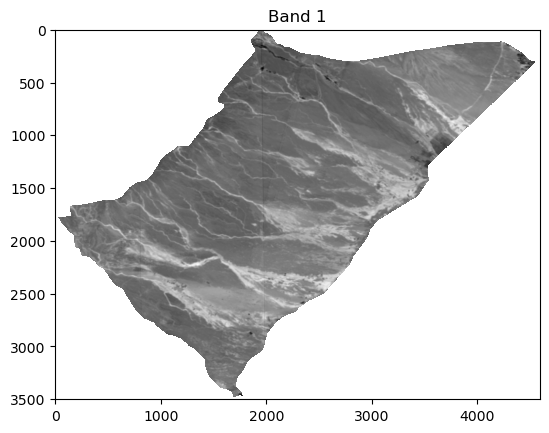

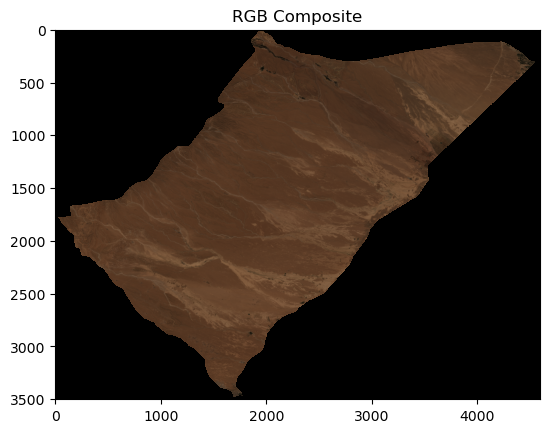

In [61]:
import rasterio
import matplotlib.pyplot as plt

# Load image
with rasterio.open("AI_Baten_S2_202503.tif") as src:
    print(src.count)        # number of bands:35?
    print(src.descriptions) # band names (if present)
    img = src.read()  # shape: (bands, height, width)
    
# For single band:
plt.imshow(img[0], cmap='gray')
plt.title("Band 1")
plt.show()

# For RGB composite (assuming bands 4,3,2 = R,G,B):
rgb = img[[3,2,1], :, :]  # rasterio is 1-indexed, 0 = band1
# Transpose to (height, width, bands)
rgb_plot = rgb.transpose(1,2,0)
plt.imshow(rgb_plot)
plt.title("RGB Composite")
plt.show()

In [84]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

# Paths to your tiles
tile_paths = ["Bouarfa_S2_202503_1.tif", "Bouarfa_S2_202503_2.tif"]

# ----------------------------
# Step 1: Load and plot individual tiles
# ----------------------------
for i, path in enumerate(tile_paths, 1):
    with rasterio.open(path) as src:
        img = src.read()  # shape: (bands, rows, cols)
        profile = src.profile
        print(f"Tile {i} shape:", img.shape, "dtype:", img.dtype)

Tile 1 shape: (35, 5514, 4884) dtype: float32
Tile 2 shape: (35, 5514, 5632) dtype: float32


In [87]:
# ----------------------------
# Step 2: Mosaic the tiles
# ----------------------------
from rasterio.merge import merge
import numpy as np
import rasterio

src_files_to_mosaic = [rasterio.open(p) for p in tile_paths]
mosaic, out_transform = merge(src_files_to_mosaic)

# The mosaic has shape (bands, rows, cols)
print("Mosaic shape:", mosaic.shape)

# All bands in the mosaic
all_bands = ('B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12',
             'AOT','WVP','SCL','TCI_R','TCI_G','TCI_B','MSK_CLDPRB','MSK_SNWPRB',
             'QA10','QA20','QA60','MSK_CLASSI_OPAQUE','MSK_CLASSI_CIRRUS',
             'MSK_CLASSI_SNOW_ICE','NDVI','NDMI','NBR','SAVI','EVI','MSAVI',
             'MNDWI','NDBI','BSI')

# Bands you want to keep
keep_bands = ('B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12',
              'NDVI','NDMI','NBR','SAVI','EVI','MSAVI','MNDWI','NDBI','BSI')

# Get indices of bands to keep
indices = [all_bands.index(b) for b in keep_bands]

# Subset the mosaic array
mosaic_subset = mosaic[indices, :, :]

# Update profile for saving
out_meta = src_files_to_mosaic[0].profile.copy()
out_meta.update({
    "height": mosaic_subset.shape[1],
    "width": mosaic_subset.shape[2],
    "count": len(keep_bands),
    "transform": out_transform,
    "dtype": "float32" 
})

# Save subset mosaic
with rasterio.open("Bouarfa_S2_202503_mosaic_subset.tif", "w", **out_meta) as dest:
    print("Saved mosaic shape:", dest.shape)
    dest.write(mosaic_subset)

MemoryError: Unable to allocate 3.51 GiB for an array with shape (35, 5514, 4884) and data type float32

# Frist classification version

In [269]:
# =========================================================
# PARAMETERS
# =========================================================

PARAMS = {
    "study_area_asset": "projects/rse-global-wetlands/assets/Bouarfa_study_area",
    "study_area_asset_EM": "projects/rse-global-wetlands/assets/mgrs_NW_grid_EM_boundary",
    "training_asset": "projects/rse-global-wetlands/assets/Phy_Bouarfa_train",
    "training_asset_EM":"projects/rse-global-wetlands/assets/Phy_EaternMorocco_train"
    "waterway": "projects/rse-global-wetlands/assets/OSM_AF_Waterways_Bouarfa",
    "populated_places":"projects/rse-global-wetlands/assets/hotosm_mar_populated_places_polygons_bouarfa",
    "building":"projects/rse-global-wetlands/assets/hotosm_mar_buildings_polygons_bouarfa",
    "anthropized_land":"projects/rse-global-wetlands/assets/Bouarfa_anthropized_land",

    "classification_start": "2025-03-01",
    "classification_end": "2025-03-31",

    "water_start": "2024-09-01",
    "water_end": "2024-09-30",

    "cloud_threshold": 10,
    "ndwi_threshold": 0.2,
    "ndvi_threshold": 0.2,

    "use_dem": True,
    "use_water_mask": True,
    "use_anthro_mask": False,

    "n_trees": 500,

    "predictor_bands": [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI'
    ]
}

CLASS_DICT = {
    'Herb steppe': 0,
    'Gully': 1,
    'Daya': 2,
    'Dune': 3,
    'Wadi': 4,
    'Fallow': 5,
    'Shrub steppe': 6,
    'Saline steppe': 7,
    'Annual cultures': 8,
    'Esparto grass steppe': 9
}

# =========================================================
# CLASS ENCODING
# =========================================================

def encode_classes(training_fc):

    class_dict = ee.Dictionary(CLASS_DICT)

    def map_function(feature):
        habitat = feature.get('Habitat')
        class_id = class_dict.get(habitat)
        return feature.set('class_id', class_id)

    return training_fc.map(map_function)

# =========================================================
# LOAD ASSETS
# =========================================================

# def load_assets(params):
#     study_area = ee.FeatureCollection(params["study_area_asset"])
#     training_fc = ee.FeatureCollection(params["training_asset"])
#     return study_area, training_fc

def load_assets(params):

    study_area = ee.FeatureCollection(params["study_area_asset"])
    training_fc = ee.FeatureCollection(params["training_asset"])

    waterway = ee.FeatureCollection(params["waterway"])
    populated = ee.FeatureCollection(params["populated_places"])
    buildings = ee.FeatureCollection(params["building"])
    anthropized = ee.FeatureCollection(params["anthropized_land"])

    return study_area, training_fc, waterway, populated, buildings, anthropized


# =========================================================
# SENTINEL-2 PREPROCESSING
# =========================================================

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000)

def load_sentinel(start, end, study_area, cloud_thresh):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(study_area)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
        .map(mask_s2_clouds)
        .median()
        .clip(study_area)
    )

# =========================================================
# INDICES
# =========================================================

def add_indices(image):

    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndmi = image.normalizedDifference(['B8', 'B11']).rename('NDMI')
    nbr  = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI_March')

    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('SAVI')

    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')

    msavi = image.expression(
        '(2*NIR + 1 - sqrt((2*NIR + 1)**2 - 8*(NIR - RED))) / 2',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('MSAVI')

    return image.addBands([ndvi, ndmi, nbr, ndwi, savi, evi, msavi])

# =========================================================
# TERRAIN
# =========================================================

def add_terrain(image, study_area):

    dem_ic = ee.ImageCollection("COPERNICUS/DEM/GLO30")

    dem = dem_ic.mosaic().clip(study_area).select('DEM').rename('Elevation')

    slope = ee.Terrain.slope(dem).rename('Slope')
    aspect = ee.Terrain.aspect(dem).rename('Aspect')
    hillshade = ee.Terrain.hillshade(dem).rename('Hillshade')
    # add later how to calculate the TRI=Terrain Ruggedness Index
    # tri = dem.focal_stdDev(radius=3, units='pixels').rename('TRI')
    
    return image.addBands([dem, slope, aspect, hillshade])

# =========================================================
# VECTOR --> RASTER SAFE CONVERSION
# =========================================================
def fc_to_mask(fc, study_area):
    return ee.Image().byte().paint(fc, 1).clip(study_area).gt(0)
    
# =========================================================
# WATER MASK
# =========================================================
def create_water_mask(params, study_area, waterway_fc):

    sept_img = load_sentinel(
        params["water_start"],
        params["water_end"],
        study_area,
        params["cloud_threshold"]
    )

    ndwi = sept_img.normalizedDifference(['B3','B8'])
    water_ndwi = ndwi.gt(params["ndwi_threshold"])

    osm_water = fc_to_mask(waterway_fc, study_area)

    return water_ndwi.Or(osm_water)

def create_veg_mask(image, threshold):
    ndvi = image.select('NDVI')
    return ndvi.gt(threshold)

def create_anthropogenic_mask(populated, buildings, anthropized):

    pop_mask = populated.reduceToImage(['system:index'], ee.Reducer.first()).gt(0)
    build_mask = buildings.reduceToImage(['system:index'], ee.Reducer.first()).gt(0)
    anth_mask = anthropized.reduceToImage(['system:index'], ee.Reducer.first()).gt(0)

    return pop_mask.Or(build_mask).Or(anth_mask)
    
# =========================================================
# BUILD FEATURE STACK
# =========================================================
def build_feature_stack(params):

    (study_area, training_fc,
     waterway, populated,
     buildings, anthropized) = load_assets(params)

    image = load_sentinel(
        params["classification_start"],
        params["classification_end"],
        study_area,
        params["cloud_threshold"]
    )

    image = add_indices(image)

    if params["use_dem"]:
        image = add_terrain(image, study_area)

    if params["use_water_mask"]:
        water_mask = create_water_mask(params, study_area, waterway)
        image = image.updateMask(water_mask.Not())

    if params["use_anthro_mask"]:
        anth_mask = fc_to_mask(populated, study_area) \
            .Or(fc_to_mask(buildings, study_area)) \
            .Or(fc_to_mask(anthropized, study_area))
        image = image.updateMask(anth_mask.Not())

    return image, training_fc, study_area

# =========================================================
# SAMPLING
# =========================================================

def sample_data(image, training_fc, params):

    predictors = params["predictor_bands"]

    samples = image.select(predictors).sampleRegions(
        collection=training_fc,
        properties=['class_id'],
        scale=10,
        geometries=False
    )

    samples = samples.randomColumn('random')

    train = samples.filter(ee.Filter.lt('random', 0.7))
    test  = samples.filter(ee.Filter.gte('random', 0.7))

    print("Sample size:", samples.size().getInfo())

    return train, test

# =========================================================
# RANDOM FOREST
# =========================================================

def train_rf(train_set, params):

    return ee.Classifier.smileRandomForest(
        numberOfTrees=params["n_trees"]
    ).train(
        features=train_set,
        classProperty='class_id',
        inputProperties=params["predictor_bands"]
    )

# =========================================================
# ACCURACY
# =========================================================

def assess_accuracy(classifier, test_set):

    validation = test_set.classify(classifier)
    cm = validation.errorMatrix('class_id','classification')

    return {
        "OA": cm.accuracy().getInfo(),
        "Kappa": cm.kappa().getInfo()
    }

# =========================================================
# RUN
# =========================================================

def run_experiment(params):

    image, training_fc, study_area = build_feature_stack(params)

    training_fc = encode_classes(training_fc)

    train, test = sample_data(image, training_fc, params)

    classifier = train_rf(train, params)

    accuracy = assess_accuracy(classifier, test)

    classified = image.select(params["predictor_bands"]) \
        .classify(classifier)

    return classified, classifier, accuracy

In [272]:
def sample_data(image, training_fc, params):

    predictors = params["predictor_bands"]

    samples = image.select(predictors).sampleRegions(
        collection=training_fc,
        properties=['class_id'],
        scale=10,
        geometries=True
    )

    samples = samples.randomColumn('random')

    train = samples.filter(ee.Filter.lt('random', 0.7))
    test  = samples.filter(ee.Filter.gte('random', 0.7))

    print("Sample size:", samples.size().getInfo())
    print("Train size:", train.size().getInfo())
    print("Test size:", test.size().getInfo())

    return train, test
    
# def train_rf(train_set, image, params):

#     classifier = ee.Classifier.smileRandomForest(
#         numberOfTrees=params["n_trees"]
#     ).train(
#         features=train_set,
#         # classProperty='Habitat',
#         classProperty='class_id',
#         inputProperties=params["predictor_bands"]
#     )

#     return classifier

def train_rf(train_set, params):

    classifier = ee.Classifier.smileRandomForest(
        numberOfTrees=params["n_trees"]
    ).train(
        features=train_set,
        classProperty='class_id',
        inputProperties=params["predictor_bands"]
    )

    return classifier


# def assess_accuracy(classifier, test_set):

#     validation = test_set.classify(classifier)
#     cm = validation.errorMatrix('class_id','classification')

#     return {
#         "confusion_matrix": cm.getInfo(),
#         "overall_accuracy": cm.accuracy().getInfo(),
#         "kappa": cm.kappa().getInfo()
#     }

def assess_accuracy(classifier, test_set):

    validation = test_set.classify(classifier)

    cm = validation.errorMatrix('class_id', 'classification')

    results = {
        "confusion_matrix": cm.getInfo(),
        "overall_accuracy": cm.accuracy().getInfo(),
        "kappa": cm.kappa().getInfo(),
        "producers_accuracy": cm.producersAccuracy().getInfo(),
        "users_accuracy": cm.consumersAccuracy().getInfo()
    }

    print("\n===== CONFUSION MATRIX =====")
    print(results["confusion_matrix"])
    print("\nOverall Accuracy:", results["overall_accuracy"])
    print("Kappa:", results["kappa"])
    print("\nProducer Accuracy:", results["producers_accuracy"])
    print("User Accuracy:", results["users_accuracy"])

    return results
    
def classify_image(image, classifier, params):

    predictors = params["predictor_bands"]

    classified = image.select(predictors).classify(classifier)

    return classified

def run_experiment(params):

    image, training_fc, study_area = build_feature_stack(params)

    training_fc = encode_classes(training_fc)

    train, test = sample_data(image, training_fc, params)

    classifier = train_rf(train, params)

    accuracy = assess_accuracy(classifier, test)

    classified = classify_image(image, classifier, params)

    return classified, classifier, accuracy


In [273]:
# Base-classification workframe
PARAMS["use_dem"] = False
PARAMS["use_water_mask"] = False # water may mask by polygons

predictor_bands = ['B2','B3','B4','B8','B11','B12',  # spectral
                   'NDVI','NDMI','NBR','SAVI','EVI','MSAVI']
classified, classifier, results_base = run_experiment(PARAMS)

Sample size: 4515
Train size: 3208
Test size: 1307

===== CONFUSION MATRIX =====
[[575, 3, 0, 6, 6, 1, 7, 4, 9, 0], [12, 39, 0, 0, 5, 0, 4, 0, 1, 0], [2, 0, 4, 0, 0, 0, 1, 0, 0, 0], [8, 3, 0, 70, 2, 0, 3, 0, 1, 0], [23, 0, 0, 0, 137, 0, 4, 0, 3, 3], [9, 0, 0, 0, 1, 4, 0, 0, 0, 0], [13, 3, 0, 1, 7, 0, 172, 0, 2, 0], [7, 0, 0, 0, 1, 0, 0, 11, 1, 0], [22, 1, 0, 1, 1, 0, 1, 0, 83, 0], [8, 1, 0, 0, 2, 0, 1, 0, 0, 18]]

Overall Accuracy: 0.8515684774292273
Kappa: 0.7897288412770282

Producer Accuracy: [[0.9410801963993454], [0.639344262295082], [0.5714285714285714], [0.8045977011494253], [0.8058823529411765], [0.2857142857142857], [0.8686868686868687], [0.55], [0.7614678899082569], [0.6]]
User Accuracy: [[0.8468335787923417, 0.78, 1, 0.8974358974358975, 0.845679012345679, 0.8, 0.8911917098445595, 0.7333333333333333, 0.83, 0.8571428571428571]]


In [276]:
import pandas as pd

cm = results_base["confusion_matrix"]
# Class names in correct order
class_names = [
    'Herb steppe','Gully','Daya','Dune','Wadi',
    'Fallow','Shrub steppe','Saline steppe',
    'Annual cultures','Esparto grass steppe'
]

df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

df_cm.to_csv("confusion_matrix.csv")

In [271]:
results_base

{'OA': 0.8489857250187829, 'Kappa': 0.7905984511559975}

In [ ]:
if PARAMS["use_dem"]:
    PARAMS["predictor_bands"] += ['Elevation','Slope','Aspect']


In [260]:
results_base

{'OA': 0.8489857250187829, 'Kappa': 0.7905984511559975}

### Runable version

In [207]:
study_area, train = load_assets(PARAMS)

print("Properties of study area:", study_area.propertyNames().getInfo())
print("Number of study area:", study_area.size().getInfo()) #210
print("Number of training features:", train.size().getInfo()) #210

first_feature = train.first()
print("Properties:",train.propertyNames().getInfo())

Properties of study area: ['system:version', 'system:id', 'system:asset_size']
Number of study area: 1
Number of training features: 210
Properties: ['system:version', 'system:id', 'system:asset_size']


In [208]:
dem_test = ee.ImageCollection("COPERNICUS/DEM/GLO30").mosaic()
print(dem_test.bandNames().getInfo()) #['DEM', 'EDM', 'FLM', 'HEM', 'WBM']

['DEM', 'EDM', 'FLM', 'HEM', 'WBM']


In [209]:
image, training_fc = build_feature_stack(PARAMS)
print("Band names:")
print(image.bandNames().getInfo())
print("Projection:")
print(image.projection().getInfo())
print("Pixel count (approx):")
print(
    image.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=training_fc.geometry(),
        scale=10,
        maxPixels=1e9
    ).getInfo()
)

Band names:
['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDMI', 'NBR', 'NDWI_March', 'SAVI', 'EVI', 'MSAVI']
Projection:
{'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}
Pixel count (approx):
{'AOT': 4485, 'B1': 4485, 'B11': 4485, 'B12': 4485, 'B2': 4485, 'B3': 4485, 'B4': 4485, 'B5': 4485, 'B6': 4485, 'B7': 4485, 'B8': 4485, 'B8A': 4485, 'B9': 4485, 'EVI': 4485, 'MSAVI': 4485, 'MSK_CLASSI_CIRRUS': 4485, 'MSK_CLASSI_OPAQUE': 4485, 'MSK_CLASSI_SNOW_ICE': 4485, 'MSK_CLDPRB': 4485, 'MSK_SNWPRB': 4485, 'NBR': 4485, 'NDMI': 4485, 'NDVI': 4485, 'NDWI_March': 4485, 'QA10': 0, 'QA20': 0, 'QA60': 4485, 'SAVI': 4485, 'SCL': 4485, 'TCI_B': 4485, 'TCI_G': 4485, 'TCI_R': 4485, 'WVP': 4485}


In [138]:
training_fc = encode_classes(training_fc)
print(training_fc.first().propertyNames().getInfo())
print(training_fc.aggregate_array('Habitat').distinct().getInfo())
print(training_fc.aggregate_array('class_id').distinct().getInfo())

['class_id', 'Habitat_Pi', 'Habitat_Sy', 'Latitude', 'Exposure', 'Station_Na', 'Longitude', 'Area_M2', 'Slope_Clas', 'Elevation', 'Work_area', 'Sub_area', 'Habitat_2_', 'Area_rad', 'Station_ID', 'Precision', 'Vegetation', 'BUFF_DIST', 'Poly_Area', 'Habitat', 'Station_Da', 'system:index']
['Herb steppe', 'Gully', 'Daya', 'Dune', 'Wadi', 'Fallow', 'Shrub steppe', 'Saline steppe', 'Annual cultures', 'Esparto grass steppe']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [139]:
print("Number of training polygons:",training_fc.size().getInfo())
print("Property names:")
print(training_fc.first().propertyNames().getInfo())

print("Unique habitat classes:")
unique_classes = training_fc.aggregate_array('Habitat').distinct()
print(unique_classes.getInfo())

Number of training polygons: 210
Property names:
['class_id', 'Habitat_Pi', 'Habitat_Sy', 'Latitude', 'Exposure', 'Station_Na', 'Longitude', 'Area_M2', 'Slope_Clas', 'Elevation', 'Work_area', 'Sub_area', 'Habitat_2_', 'Area_rad', 'Station_ID', 'Precision', 'Vegetation', 'BUFF_DIST', 'Poly_Area', 'Habitat', 'Station_Da', 'system:index']
Unique habitat classes:
['Herb steppe', 'Gully', 'Daya', 'Dune', 'Wadi', 'Fallow', 'Shrub steppe', 'Saline steppe', 'Annual cultures', 'Esparto grass steppe']


In [140]:
# predictor_bands = ['B2','B3','B4','B8','B11','B12',  # spectral
#                    'NDVI','NDMI','NBR','SAVI','EVI','MSAVI']

predictor_bands = ['B2','B3','B4','B8','B11','B12',
                   'NDVI','NDMI','NBR','SAVI','EVI','MSAVI',
                   'Elevation','Slope','Aspect','Hillshade']

train, test = sample_data(predictor_bands, image, training_fc)
# print(train.first().propertyNames().getInfo())

Sample size: 4515
Train size: 3166
Test size: 1349


In [150]:
terrain_bands = ['Elevation','Slope','Aspect','Hillshade']
dem_img = add_terrain(image, study_area)

# Resample DEM to Sentinel-2 projection & scale
dem_img = dem_img.select(terrain_bands).resample('bilinear') \
            .reproject(crs=image.projection(), scale=10).unmask(-9999)

# Add terrain bands to the image
image = image.addBands(dem_img)

predictor_bands = [
    'B2','B3','B4','B8','B11','B12',
    'NDVI','NDMI','NBR','SAVI','EVI','MSAVI',
    'Elevation','Slope','Aspect','Hillshade'
]

samples = image.sampleRegions(
    collection=training_fc,
    properties=['class_id'],
    scale=10,
    geometries=True
)

# Optional: remove any samples where all predictor bands are -9999
samples = samples.filter(ee.Filter.notEquals('Elevation', -9999))

samples = samples.randomColumn('random')
train = samples.filter(ee.Filter.lt('random', 0.7))
test  = samples.filter(ee.Filter.gte('random', 0.7))

print("Train size:", train.size().getInfo())
print("Test size:", test.size().getInfo())


Train size: 0
Test size: 0


In [133]:
terrain_bands = ['Elevation','Slope','Aspect','Hillshade']
march_img = image.select(terrain_bands).unmask(-9999).addBands(
    image.select([b for b in image.bandNames().getInfo() if b not in terrain_bands])
)

print("Band names:")
print(march_img.bandNames().getInfo())

training_fc = training_fc.filter(ee.Filter.notNull(terrain_bands))
print("Traning sample size:", training_fc.size().getInfo())

Band names:
['Elevation', 'Slope', 'Aspect', 'Hillshade', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDMI', 'NBR', 'NDWI_March', 'SAVI', 'EVI', 'MSAVI']
Traning sample size: 0


In [134]:
predictor_bands = [
    'B2','B3','B4','B8','B11','B12',
    'NDVI','NDMI','NBR','SAVI','EVI','MSAVI',
    'Elevation','Slope','Aspect','Hillshade'
]

samples = image.sampleRegions(
    collection=training_fc,
    properties=['class_id'],  # your encoded class labels
    scale=10,
    geometries=True
)

samples = samples.filter(ee.Filter.notNull(predictor_bands))

# Stratified split
samples = samples.randomColumn('random')
train = samples.filter(ee.Filter.lt('random', 0.7))
test  = samples.filter(ee.Filter.gte('random', 0.7))

print("Train size:", train.size().getInfo())
print("Test size:", test.size().getInfo())


Train size: 0
Test size: 0


## Download the original Sentinel-2 Image AND DEM image

In [ ]:
study_area, train = load_assets(PARAMS)

print("Properties of study area:", study_area.propertyNames().getInfo())
print("Number of study area:", study_area.size().getInfo()) #210
print("Number of training features:", train.size().getInfo()) #210

first_feature = train.first()
print("Properties:",train.propertyNames().getInfo())

In [210]:
print(image.bandNames().getInfo())

['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDMI', 'NBR', 'NDWI_March', 'SAVI', 'EVI', 'MSAVI']


In [213]:
# ---------------------------------------
# 1 Collect DEM and related image
# ---------------------------------------

def col_terrain(study_area):

    # Load DEM collection
    dem_ic = ee.ImageCollection("COPERNICUS/DEM/GLO30")

    # Mosaic to single image
    dem = dem_ic.mosaic().clip(study_area).select('DEM').rename('Elevation')

    # Derive terrain layers
    slope = ee.Terrain.slope(dem).rename('Slope')
    aspect = ee.Terrain.aspect(dem).rename('Aspect')
    hillshade = ee.Terrain.hillshade(dem).rename('Hillshade')

    # Combine into one image
    terrain_img = dem.addBands([slope, aspect, hillshade])

    return terrain_img


In [215]:
# ---------------------------------------
# 2 Apply the collection function
# ---------------------------------------
terrain_bands = ['Elevation','Slope','Aspect','Hillshade']

dem_img = col_terrain(study_area)

# Resample to Sentinel-2 projection
dem_img = dem_img.select(terrain_bands) \
    .resample('bilinear') \
    .reproject(crs=image.projection(), scale=10) \
    .unmask(-9999)

print(dem_img.bandNames().getInfo())

# ---------------------------------------
# 3 Export IMG to Google Drive
# ---------------------------------------
# aoi = study_area
task = ee.batch.Export.image.toDrive(
    image=dem_img.toFloat(),
    description='Bouarfa_DEM',
    folder='GEE_exports',
    fileNamePrefix='Bouarfa_DEM',
    scale=10,
    region=study_area.geometry(),
    crs=image.projection().crs(),
    maxPixels=1e13
)

task.start()
print("DEM export started.")

['Elevation', 'Slope', 'Aspect', 'Hillshade']
DEM export started.


#### S2 image download

In [184]:
print(
    image.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=training_fc.geometry(),
        scale=10,
        maxPixels=1e9
    ).getInfo()
)

{'AOT': 4485, 'Aspect': 4485, 'Aspect_1': 4485, 'B1': 4485, 'B11': 4485, 'B12': 4485, 'B2': 4485, 'B3': 4485, 'B4': 4485, 'B5': 4485, 'B6': 4485, 'B7': 4485, 'B8': 4485, 'B8A': 4485, 'B9': 4485, 'EVI': 4485, 'Elevation': 4485, 'Elevation_1': 4485, 'Hillshade': 4485, 'Hillshade_1': 4485, 'MSAVI': 4485, 'MSK_CLASSI_CIRRUS': 4485, 'MSK_CLASSI_OPAQUE': 4485, 'MSK_CLASSI_SNOW_ICE': 4485, 'MSK_CLDPRB': 4485, 'MSK_SNWPRB': 4485, 'NBR': 4485, 'NDMI': 4485, 'NDVI': 4485, 'NDWI_March': 4485, 'QA10': 0, 'QA20': 0, 'QA60': 4485, 'SAVI': 4485, 'SCL': 4485, 'Slope': 4485, 'Slope_1': 4485, 'TCI_B': 4485, 'TCI_G': 4485, 'TCI_R': 4485, 'WVP': 4485}


In [186]:
# ---------------------------------------
# 1️ Select only needed bands
# ---------------------------------------
export_bands = [
    # Sentinel-2 spectral bands
    'B2','B3','B4','B5','B6','B7','B8A','B8','B11','B12',

    # Spectral indices
    'NDVI','NDMI','NBR','SAVI','EVI','MSAVI','NDWI_March',

    # Terrain metrics
    'Elevation','Slope','Aspect','Hillshade'
]

export_image = image.select(export_bands).mosaic()
export_image = export_image.toFloat()
print("Bands being exported:")
print(export_image.bandNames().getInfo())


# ---------------------------------------
# 2️ Export to Google Drive
# ---------------------------------------

task = ee.batch.Export.image.toDrive(
    image=export_image,
    description='Habitat_Sentinel2_March2025',
    folder='GEE_exports',
    fileNamePrefix='Bouarfa_Sentinel2_March2025',
    scale=10,
    region=aoi.geometry(),
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Export started. Check the GEE Tasks tab.")


Bands being exported:
['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B8', 'B11', 'B12', 'NDVI', 'NDMI', 'NBR', 'SAVI', 'EVI', 'MSAVI', 'NDWI_March', 'Elevation', 'Slope', 'Aspect', 'Hillshade']
Export started. Check the GEE Tasks tab.


In [189]:
import os
indir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/'
rafile = [os.path.join(indir,'Bouarfa_Sentinel2_March2025-1.tif'),
          os.path.join(indir,'Bouarfa_Sentinel2_March2025-2.tif'),
          os.path.join(indir,'Bouarfa_Sentinel2_March2025_mosaic.tif')]

print(rafile)

['C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/Bouarfa_Sentinel2_March2025-1.tif', 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/Bouarfa_Sentinel2_March2025-2.tif', 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/Bouarfa_Sentinel2_March2025_mosaic.tif']


In [197]:
#### Mosaic the downlaod two Sentinel-2 images
import os
import rasterio
import numpy as np
from rasterio.merge import merge

indir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/'
rafile = [os.path.join(indir,'Bouarfa_Sentinel2_March2025-1.tif'),
          os.path.join(indir,'Bouarfa_Sentinel2_March2025-2.tif'),
          os.path.join(indir,'Bouarfa_Sentinel2_March2025_mosaic.tif')]
          

src1 = rasterio.open(rafile[0])
src2 = rasterio.open(rafile[1])

mosaic, out_trans = merge([src1, src2])
# Replace NaN with 0
mosaic = np.nan_to_num(mosaic, nan=0)

out_meta = src1.meta.copy()
out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "nodata": 0
})

with rasterio.open(rafile[2], "w", **out_meta) as dest:
    dest.write(mosaic)
    print(f'The Bouarfa Sentinel-2 March 2025 imagery was successfully saved in {rafile[2]}.')

The Bouarfa Sentinel-2 March 2025 imagery was successfully saved in C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/Bouarfa_Sentinel2_March2025_mosaic.tif.


In [199]:
with rasterio.open(rafile[2]) as src:
    # ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B8', 'B11', 'B12', 'NDVI', 'NDMI', 'NBR', 'SAVI', 'EVI', 'MSAVI', 'NDWI_March', 'Elevation', 'Slope', 'Aspect', 'Hillshade']
    print("Band count:", src.count)
    print("Band descriptions:", src.descriptions)
    print("Dtypes:", src.dtypes)
    
    band = src.read(1)
    print("Min:", band.min())
    print("Max:", band.max())

# Min: nan
# Max: nan

Min: 0.0
Max: 0.8424


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


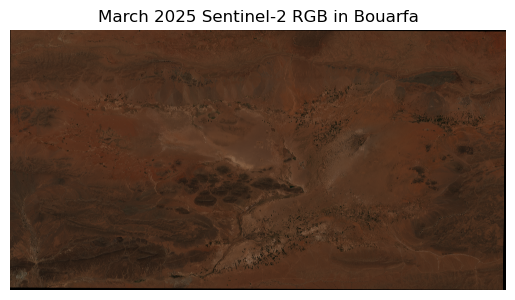

In [201]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

indir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/'
rafile = [os.path.join(indir,'Bouarfa_Sentinel2_March2025-1.tif'),
          os.path.join(indir,'Bouarfa_Sentinel2_March2025-2.tif'),
          os.path.join(indir,'Bouarfa_Sentinel2_March2025_mosaic.tif')]

with rasterio.open(rafile[2]) as src:
    rgb = src.read([3,2,1])  # if B4,B3,B2 order
    rgb = rgb.transpose(1,2,0)

# Percentile stretch
p2, p98 = np.percentile(rgb, (2,98))
rgb_stretch = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.imshow(rgb)
# plt.imshow(rgb_stretch)
plt.axis("off")
plt.title("March 2025 Sentinel-2 RGB in Bouarfa")
plt.show()

## Apply the classifier

In [160]:
classified = classify_image(image, classifier, PARAMS)

In [259]:
# Visualize the finnal classified map
import geemap
from matplotlib.colors import to_rgb

# # --------------------------
# # 1️ Load Study Area & Training Polygons
# # --------------------------
# study_area, training_fc = load_assets(PARAMS)
# print("Number of training polygons:", training_fc.size().getInfo())

# --------------------------
# 2️ Load / visualize classified image
# --------------------------
Map = geemap.Map()
Map.centerObject(study_area, 12)  # aoi = your study area

# Define your classes and colors clearly
habitat_labels = [
    'Herb steppe', 'Gully', 'Daya', 'Dune', 'Wadi', 
    'Fallow', 'Shrub steppe', 'Saline steppe', 'Annual cultures', 'Esparto grass steppe'
]

# Using simple names or Hex strings works best for the palette
palette = [
    '#FFFF00', # 0: Herb steppe (Yellow)
    '#008000', # 1: Gully (Green)
    '#A52A2A', # 2: Daya (Brown)
    '#0000FF', # 3: Dune (Blue)
    '#808080', # 4: Wadi (Gray)
    '#FF0000', # 5: Fallow (Red)
    '#FFA500', # 6: Shrub steppe (Orange)
    '#800080', # 7: Saline steppe (Purple)
    '#FFC0CB', # 8: Annual cultures (Pink)
    '#00FFFF'  # 9: Esparto grass steppe (Cyan)
]

Map.addLayer(classified, {'min':0, 'max':9, 'palette': palette}, 'Habitat Classification')
# Map.addLayer(classified, {'min':0, 'max':9, 'palette': ['yellow','green','brown','blue','gray','red','orange','purple','pink','cyan']}, 'Habitat Classification')


# --------------------------
# 3️ Overlay training polygons for reference
# --------------------------
Map.addLayer(training_fc.style(color='black', fillColor='00000000', width=2), {}, 'Training polygons')


# --------------------------
# 4️ Add legend
# --------------------------
# Zip labels and palette together for a clean dictionary
legend_dict = dict(zip(habitat_labels, palette))
# Map.add_legend(title="Habitat Classes", legend_dict=legend_dict)

Map


Map(center=[32.420845633778, -2.3608082721634105], controls=(WidgetControl(options=['position', 'transparent_b…

In [261]:
# Export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=classified,
    description='Habitat_Classification_March2025',
    folder='GEE_exports',
    fileNamePrefix='Bouarfa_Habitat2',
    scale=10,
    region=aoi.geometry(),
    crs='EPSG:4326',
    maxPixels=1e13
)
task.start()
print("Export started, check GEE Tasks tab.")


Export started, check GEE Tasks tab.


### Accuracy and Confusion matrix

In [114]:
print(results_base)

{'confusion_matrix': [[575, 3, 0, 6, 6, 1, 7, 4, 9, 0], [12, 39, 0, 0, 5, 0, 4, 0, 1, 0], [2, 0, 4, 0, 0, 0, 1, 0, 0, 0], [8, 3, 0, 70, 2, 0, 3, 0, 1, 0], [23, 0, 0, 0, 137, 0, 4, 0, 3, 3], [9, 0, 0, 0, 1, 4, 0, 0, 0, 0], [13, 3, 0, 1, 7, 0, 172, 0, 2, 0], [7, 0, 0, 0, 1, 0, 0, 11, 1, 0], [22, 1, 0, 1, 1, 0, 1, 0, 83, 0], [8, 1, 0, 0, 2, 0, 1, 0, 0, 18]], 'overall_accuracy': 0.8515684774292273, 'kappa': 0.7897288412770282}


In [76]:
# Apply water mask workframe
PARAMS["use_water_mask"] = True

results_water = run_experiment(PARAMS)

Sample size: 4515
Train size: 3114
Test size: 1401


In [115]:
print(results_water)

{'confusion_matrix': [[613, 3, 0, 2, 8, 0, 3, 4, 6, 0], [14, 49, 0, 1, 2, 0, 0, 1, 0, 1], [0, 0, 5, 0, 0, 0, 1, 0, 0, 0], [16, 2, 0, 74, 2, 0, 0, 0, 5, 0], [38, 3, 0, 1, 148, 0, 3, 0, 2, 1], [12, 0, 0, 0, 0, 12, 0, 0, 1, 0], [22, 0, 0, 0, 4, 1, 174, 0, 3, 0], [6, 0, 0, 0, 0, 1, 1, 16, 0, 0], [18, 0, 0, 2, 4, 0, 0, 0, 84, 0], [6, 1, 0, 0, 4, 0, 1, 0, 0, 20]], 'overall_accuracy': 0.8529621698786581, 'kappa': 0.792570051072993}


In [122]:
# Apply terrian and water parameters
PARAMS["use_dem"] = True

if PARAMS["use_dem"]:
    PARAMS["predictor_bands"] = [
        'B2','B3','B4','B8','B11','B12',
        'NDVI','NDMI','NBR','SAVI','EVI','MSAVI',
        'Elevation','Slope','Aspect','Hillshade']
    
results_full = run_experiment(PARAMS)


Sample size: 4515
Train size: 3152
Test size: 1363


EEException: Property 'Elevation' of feature '00000000000000000000_0' is missing.

In [102]:
comparison = pd.DataFrame([
    {"Model":"Base", **results_base},
    {"Model":"WaterMask", **results_water}
    # {"Model":"FullModel", **results_full}
])

comparison


,Model,confusion_matrix,overall_accuracy,kappa
0,Base,"[[575, 3, 0, 6, 6, 1, 7, 4, 9, 0], [12, 39, 0,...",0.851568,0.789729
1,WaterMask,"[[613, 3, 0, 2, 8, 0, 3, 4, 6, 0], [14, 49, 0,...",0.852962,0.792570


# Apply the RF Classifer

## Old version

In [12]:
import os
import rasterio
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterio.merge import merge


# Set working directory
os.chdir(r"W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/Bouarfa_03272025_psscene_analytic_8b_sr_udm2/PSScene/")

# Verify
print(os.getcwd())

# SR 8-band files (already filtered)
sr8b_tifs = sorted([
    os.path.join(os.getcwd(), f)
    for f in os.listdir()
    if f.endswith("SR_8b.tif")
])

# AOI shapefiles
shp_dir = r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/"
in_shp_paths = [
    # 'GIS Data/habitat_mapping/study and working area/Al_Baten_study_area.shp',
    'GIS Data/habitat_mapping/study and working area/Bouarfa_study_area.shp'
]

W:\GIS_Data\SatelliteImagery\HighResolution\Morocco\Bouarfa_03272025_psscene_analytic_8b_sr_udm2\PSScene


In [14]:
# Your shapefile paths
shp_paths = [
    # r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/GIS Data/habitat_mapping/study and working area/Al_Baten_study_area.shp",
    r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/GIS Data/habitat_mapping/study and working area/Bouarfa_study_area.shp"
]

# Read shapefiles
aoi_gdfs = [gpd.read_file(p) for p in shp_paths]

# Target CRS for PlanetScope
target_crs = "EPSG:32630"

# Reproject to match PlanetScope CRS
aoi_gdfs_proj = [gdf.to_crs(target_crs) for gdf in aoi_gdfs]

# Merge into one GeoDataFrame
aoi = gpd.GeoDataFrame(pd.concat(aoi_gdfs_proj, ignore_index=True), crs=target_crs)

# Optional: dissolve to get single polygon for AOI
aoi_outline = aoi.dissolve()

# Check
print(aoi_outline.crs)

EPSG:32630


In [22]:
import os
import rasterio
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterio.merge import merge

# -------------------------------
# 1. Define directories and files
# -------------------------------
tif_dir = r"W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/Bouarfa_03272025_psscene_analytic_8b_sr_udm2/PSScene/"

# List only SR_8B.tif files
sr_files = [os.path.join(tif_dir, f) for f in os.listdir(tif_dir) if f.endswith("SR_8b.tif")]
print(f"Found {len(sr8b_tifs)} SR_8b GeoTIFFs:\n")
sr8b_tifs = sorted(sr8b_tifs)
for f in sr8b_tifs:
    print(os.path.basename(f))

with rasterio.open(sr_files[0]) as src:
    print("Bands:", src.count)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    
# -------------------------------
# 2. Load and reproject AOI shapefiles
# -------------------------------
aoi_path = r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/GIS Data/habitat_mapping/study and working area/Bouarfa_study_area.shp"
aoi = gpd.read_file(aoi_path)
target_crs = "EPSG:32630"  # PlanetScope CRS
aoi = aoi.to_crs(target_crs)


Found 12 SR_8b GeoTIFFs:

20250327_110847_56_2506_3B_AnalyticMS_SR_8b.tif
20250327_110849_82_2506_3B_AnalyticMS_SR_8b.tif
20250327_110852_09_2506_3B_AnalyticMS_SR_8b.tif
20250327_110854_35_2506_3B_AnalyticMS_SR_8b.tif
20250327_110923_45_24f8_3B_AnalyticMS_SR_8b.tif
20250327_110925_63_24f8_3B_AnalyticMS_SR_8b.tif
20250327_110927_74_2508_3B_AnalyticMS_SR_8b.tif
20250327_110927_82_24f8_3B_AnalyticMS_SR_8b.tif
20250327_110929_97_2508_3B_AnalyticMS_SR_8b.tif
20250327_110930_00_24f8_3B_AnalyticMS_SR_8b.tif
20250327_110932_20_2508_3B_AnalyticMS_SR_8b.tif
20250327_110934_42_2508_3B_AnalyticMS_SR_8b.tif
Bands: 8
CRS: EPSG:32630
Resolution: (3.0, 3.0)


In [23]:
from rasterio.merge import merge

# -------------------------------
# 3. Open all rasters
# -------------------------------
src_files_to_mosaic = [rasterio.open(fp) for fp in sr8b_tifs]

# -------------------------------
# 4. Merge/mosaic rasters
# -------------------------------
mosaic, out_transform = merge(src_files_to_mosaic)

# Metadata for the mosaic
out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform
})

# Optional: save mosaic to disk
mosaic_out_fp = os.path.join(tif_dir, "20250327_Bouarfa_mosaic_SR_8b.tif")
with rasterio.open(mosaic_out_fp, "w", **out_meta) as dest:
    dest.write(mosaic)

print(f"Mosaic saved to: {mosaic_out_fp}")

# Close opened sources
for src in src_files_to_mosaic:
    src.close()


Mosaic saved to: W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/Bouarfa_03272025_psscene_analytic_8b_sr_udm2/PSScene/20250327_Bouarfa_mosaic_SR_8b.tif


In [24]:
# -------------------------------
# 5. Plot mosaic RGB with AOI
# -------------------------------
# RGB = Red(B6), Green(B4), Blue(B2) for PlanetScope 8-band
rgb = mosaic[[5,3,1], :, :]  # rasterio uses 0-based indexing after mosaic

# Normalize for display
rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(12,12))
show(rgb_norm)
aoi.boundary.plot(color='yellow', linewidth=2)
plt.title("Mosaic of 12 PlanetScope SR Scenes (RGB) with Bouarfa AOI")
plt.show()

MemoryError: Unable to allocate 19.7 GiB for an array with shape (3, 26661, 33093) and data type float64

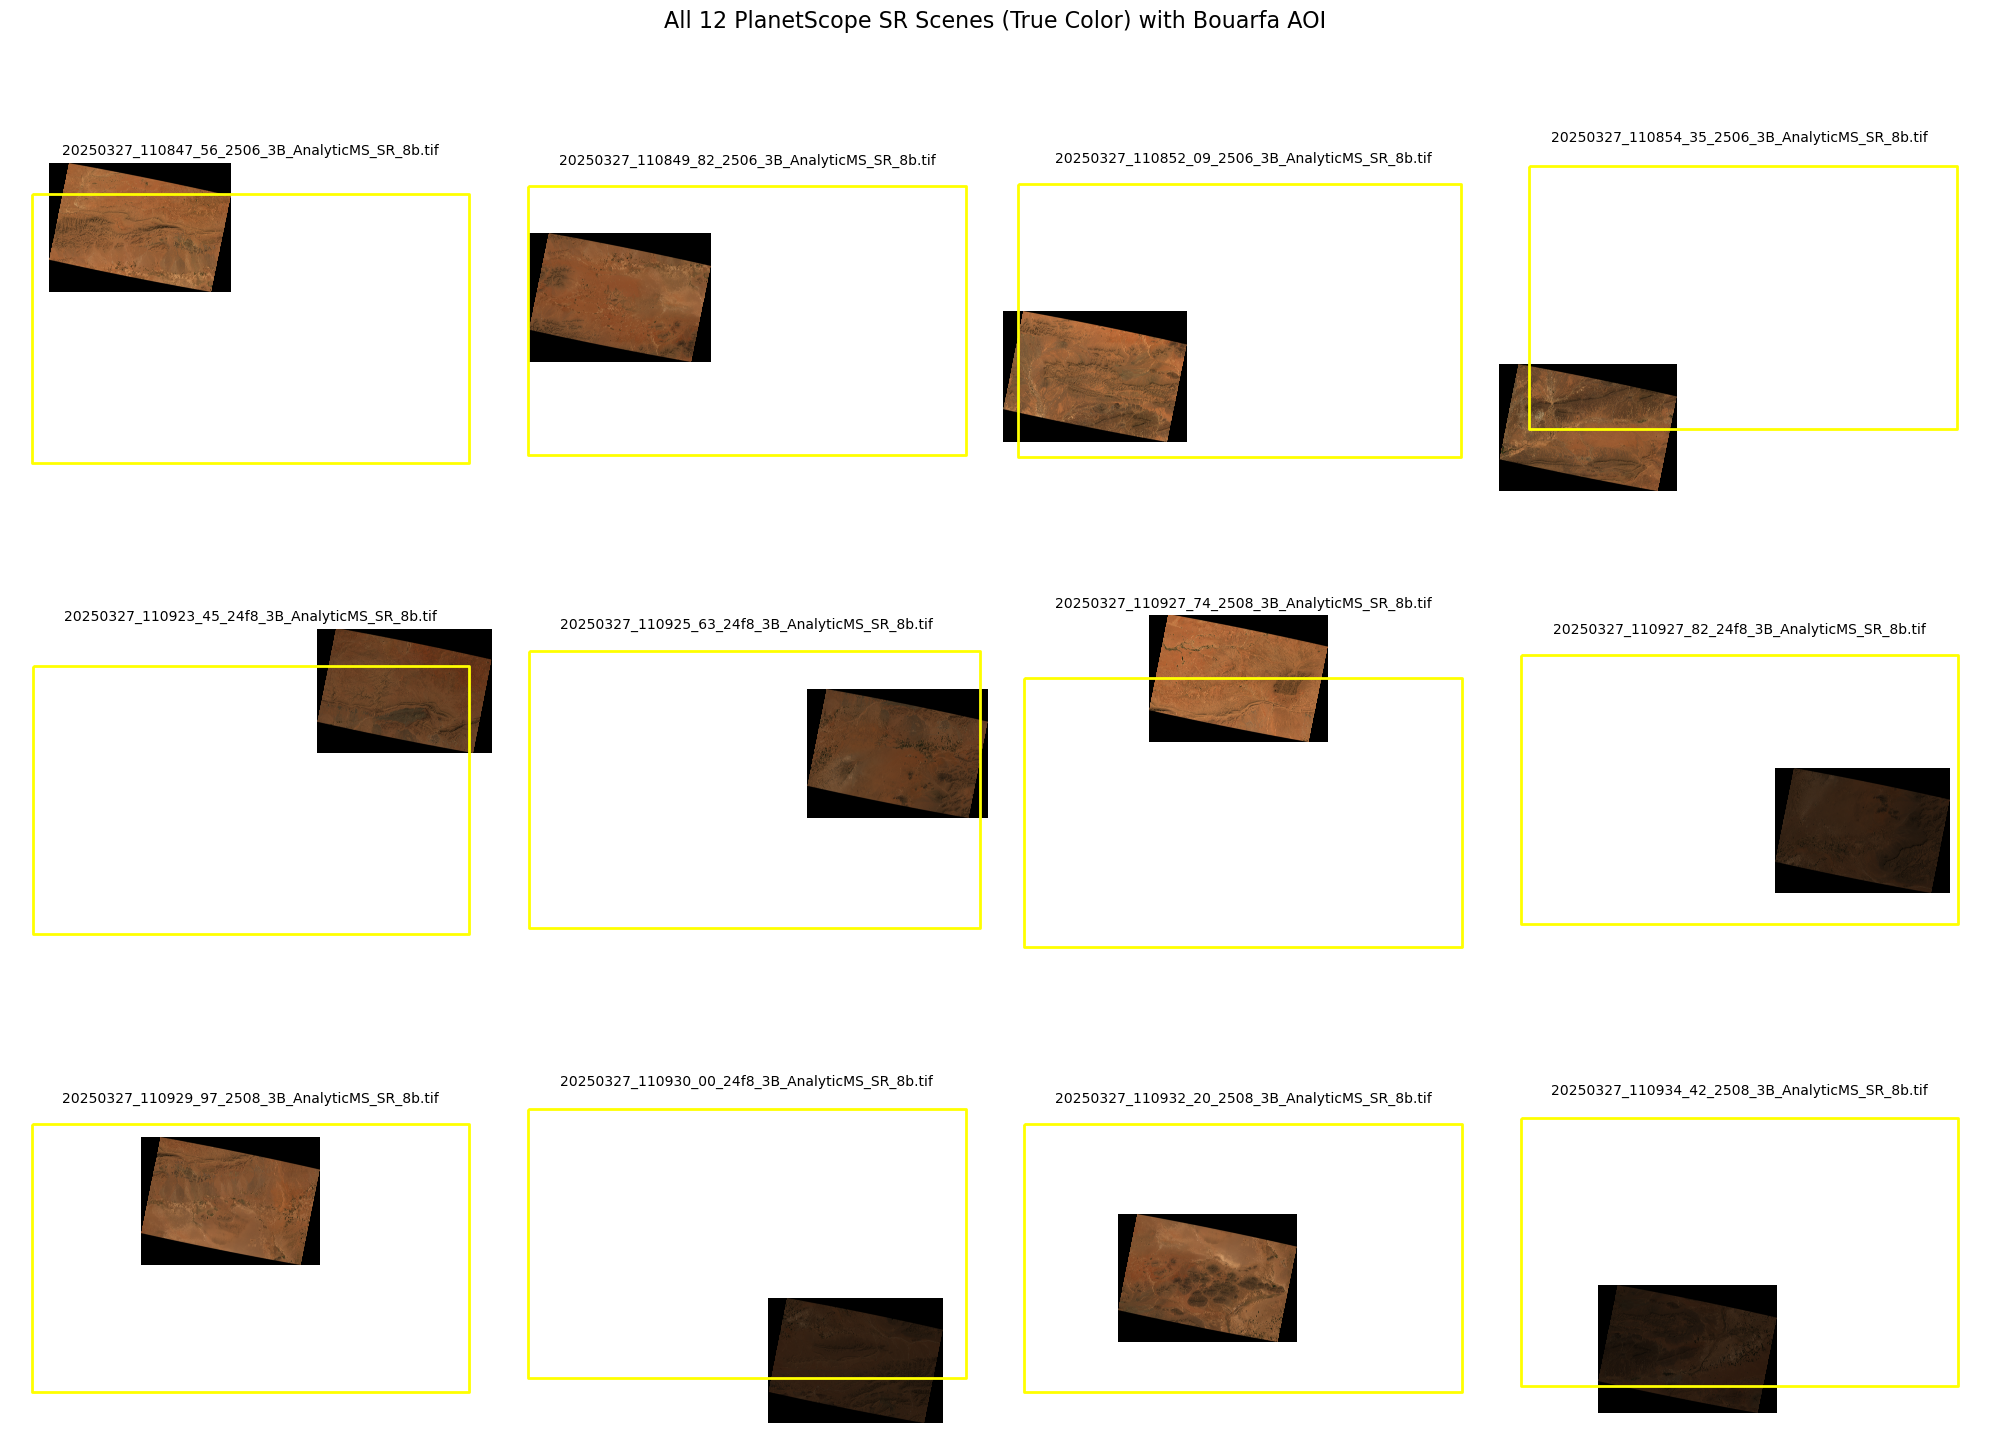

In [19]:
# -------------------------------
# 3. Plot all 12 scenes in one figure
# -------------------------------
n_scenes = len(sr8b_tifs)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # 3 rows x 4 columns
axes = axes.flatten()

for i, path in enumerate(sr8b_tifs):
    with rasterio.open(path) as src:
        # PlanetScope 8-band: RGB = Red(B6), Green(B4), Blue(B2)
        rgb = src.read([6, 4, 2])  # rasterio uses 1-based indexing
        # Normalize for display
        rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())
        # Plot on axes
        show(rgb_norm, ax=axes[i], transform=src.transform)
        aoi.boundary.plot(ax=axes[i], color='yellow', linewidth=2)
        axes[i].set_title(os.path.basename(path), fontsize=10)
        axes[i].axis('off')

plt.tight_layout()
plt.suptitle("All 12 PlanetScope SR Scenes (True Color) with Bouarfa AOI", fontsize=16, y=1.02)
plt.show()

# Old Version

In [ ]:
import os
import rasterio
# Check current working directory


# Set working directory
os.chdir(r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/GEE RS layer/")

# Verify
print(os.getcwd())

C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\07_Bustard-Project\GEE RS layer
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\07_Bustard-Project\GEE RS layer


In [4]:
import rasterio

# ---- user inputs ----
input_tifs = [
    "Landsat89_2024_AprJul_AI_Baten_Median_AllBands.tif",
    "Landsat89_2024_AprJul_Bouarfa_Median_AllBands.tif"
]
output_tifs = [
    "Landsat89_2024_AprJul_AI_Baten_NBR.tif",
    "Landsat89_2024_AprJul_Bouarfa_NBR.tif"
]
band_name = "NBR"

# ---- process each file ----
for in_file, out_file in zip(input_tifs, output_tifs):
    with rasterio.open(in_file) as src:
        band_names = src.descriptions

        if band_names is None:
            raise ValueError(f"Band names not found in {in_file} metadata.")

        if band_name not in band_names:
            raise ValueError(f"{band_name} not found in {in_file}. Available bands: {band_names}")

        band_index = band_names.index(band_name) + 1  # rasterio is 1-based
        band_data = src.read(band_index)

        profile = src.profile
        profile.update(count=1, dtype=band_data.dtype)

        with rasterio.open(out_file, "w", **profile) as dst:
            dst.write(band_data, 1)
            dst.set_band_description(1, band_name)

    print(f"Exported band '{band_name}' to {out_file}")


Exported band 'NBR' to Landsat89_2024_AprJul_AI_Baten_NBR.tif
Exported band 'NBR' to Landsat89_2024_AprJul_Bouarfa_NBR.tif


Current working directory: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\07_Bustard-Project
Original CRS of GIS Data/habitat_mapping/study and working area/Al_Baten_study_area.shp: EPSG:4326
Successfully created buffered shapefile at GIS Data/habitat_mapping/study and working area/Al_Baten_study_area_10kmbuf.shp


C:\Users\PangY\AppData\Local\Temp\ipykernel_42476\3886910494.py:48: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  buffered_gdf.to_file(out_shp)


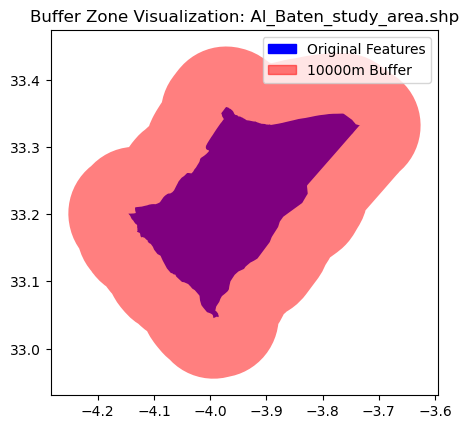

C:\Users\PangY\AppData\Local\Temp\ipykernel_42476\3886910494.py:48: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  buffered_gdf.to_file(out_shp)


Original CRS of GIS Data/habitat_mapping/study and working area/Bouarfa_study_area.shp: EPSG:9707
Successfully created buffered shapefile at GIS Data/habitat_mapping/study and working area/Bouarfa_study_area_10kmbuf.shp


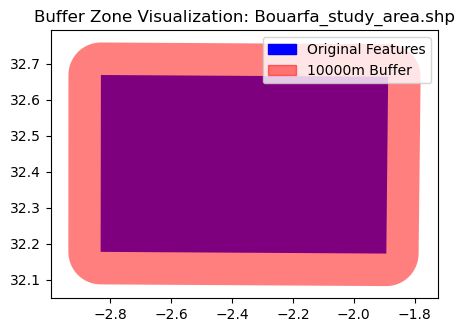

In [11]:
# creating the buffer zone
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# Set working directory
os.chdir(r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/07_Bustard-Project/")

# Verify working directory
print("Current working directory:", os.getcwd())

# Define file paths
in_shp_paths = ['GIS Data/habitat_mapping/study and working area/Al_Baten_study_area.shp',
                'GIS Data/habitat_mapping/study and working area/Bouarfa_study_area.shp']

out_shp_paths = ['GIS Data/habitat_mapping/study and working area/Al_Baten_study_area_10kmbuf.shp',
                 'GIS Data/habitat_mapping/study and working area/Bouarfa_study_area_10kmbuf.shp']

# Buffer distance in meters
buffer_distance_meters = 10000  # 10 km buffer

# Loop over all input shapefiles
for in_shp, out_shp in zip(in_shp_paths, out_shp_paths):
    
    if not os.path.exists(in_shp):
        print(f"Error: Input file not found at {in_shp}")
        continue
    
    # 1. Read the input shapefile into a GeoDataFrame
    gdf = gpd.read_file(in_shp)
    print(f"Original CRS of {in_shp}: {gdf.crs}")
    
    # 2. Reproject to a projected CRS for accurate buffering
    # UTM Zone 30N (EPSG:32630) 
    projected_crs = 'EPSG:32630' # UTM Zone 30N for Morocco
    gdf_projected = gdf.to_crs(projected_crs)
    
    # 3. Create the buffer
    gdf_projected['buffer_geometry'] = gdf_projected.buffer(buffer_distance_meters)
    
    # 4. Create a new GeoDataFrame with the buffer geometries
    buffered_gdf = gdf_projected.drop(columns=['geometry']).set_geometry('buffer_geometry')
    
    # 5. Optionally, reproject back to original CRS
    buffered_gdf = buffered_gdf.to_crs(gdf.crs)
    
    # 6. Export the buffered GeoDataFrame
    buffered_gdf.to_file(out_shp)
    print(f"Successfully created buffered shapefile at {out_shp}")
    
    # 7. Optional: Visualize
    fig, ax = plt.subplots(figsize=(5, 5))
    gdf.plot(ax=ax, color='blue')
    buffered_gdf.plot(ax=ax, color='red', alpha=0.5)
    plt.title(f"Buffer Zone Visualization: {os.path.basename(in_shp)}")
    
    # Custom legend for PatchCollection
    import matplotlib.patches as mpatches
    blue_patch = mpatches.Patch(color='blue', label='Original Features')
    red_patch  = mpatches.Patch(color='red', alpha=0.5, label=f'{buffer_distance_meters}m Buffer')
    plt.legend(handles=[blue_patch, red_patch])
    
    plt.show()


In [1]:
import os

# Check current working directory
print(os.getcwd())

# Set working directory
os.chdir(r"C:/Users/PangY/OneDrive - Smithsonian Institution/REMOTE SENSING/uav_mosaics_patch_polygons2/")

# Verify
print(os.getcwd())

C:\Users\PangY\Python-GIS
C:\Users\PangY\OneDrive - Smithsonian Institution\REMOTE SENSING\uav_mosaics_patch_polygons2


Vector CRS: EPSG:32719

Processing raster: L94L92_orthomosaic.tif
Raster CRS: EPSG:32719


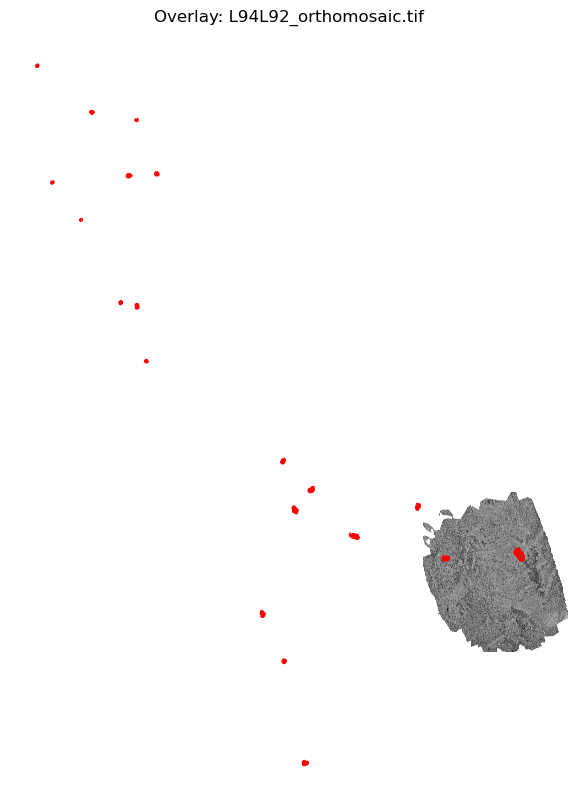


Processing raster: L77L78L79_orthomosaic.tif
Raster CRS: EPSG:5389


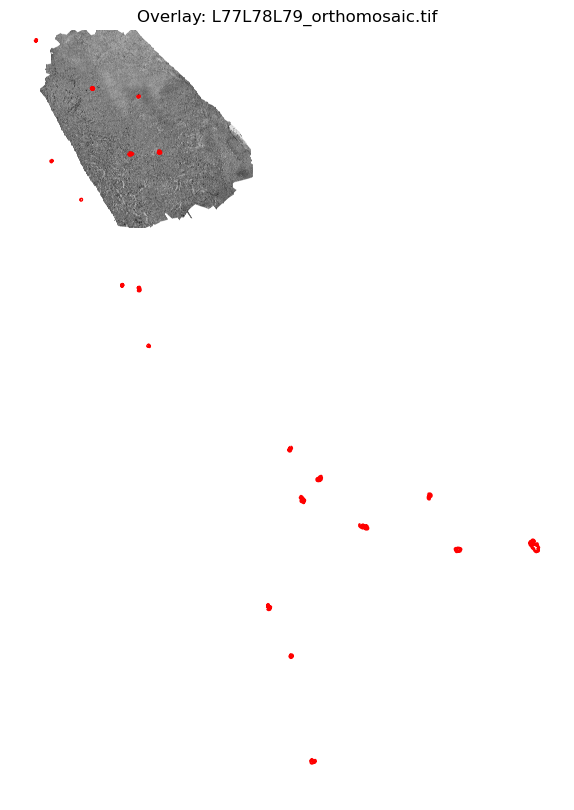


Processing raster: L70L71L73_orthomosaic.tif
Raster CRS: EPSG:5389


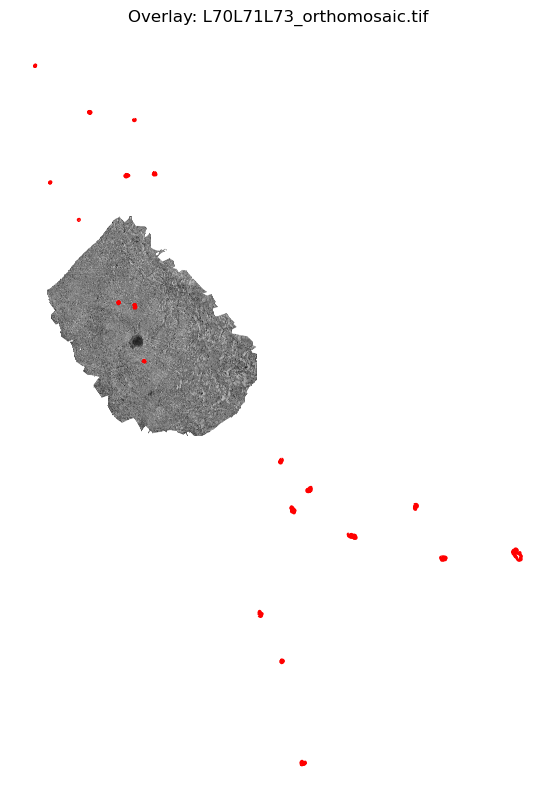


Processing raster: L58L57B_orthomosaic.tif
Raster CRS: EPSG:5389


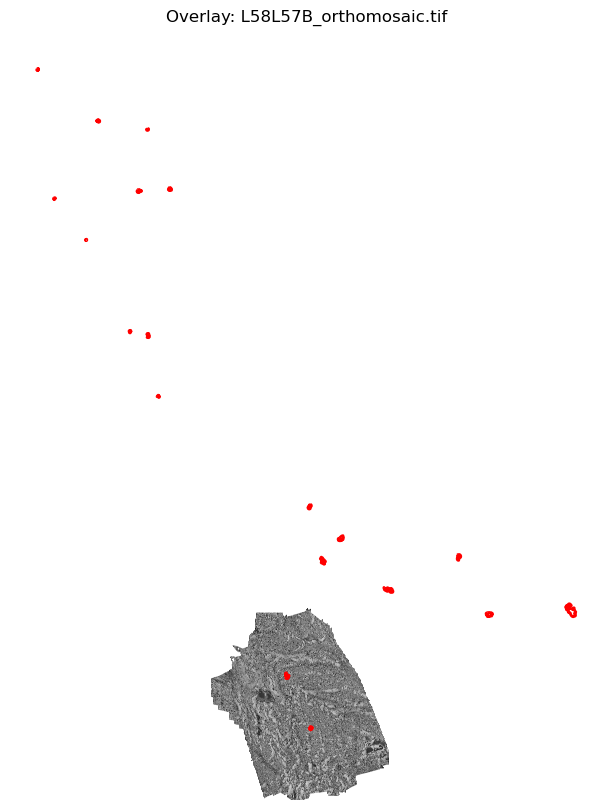


Processing raster: L57AL56_orthomosaic.tif
Raster CRS: EPSG:5389


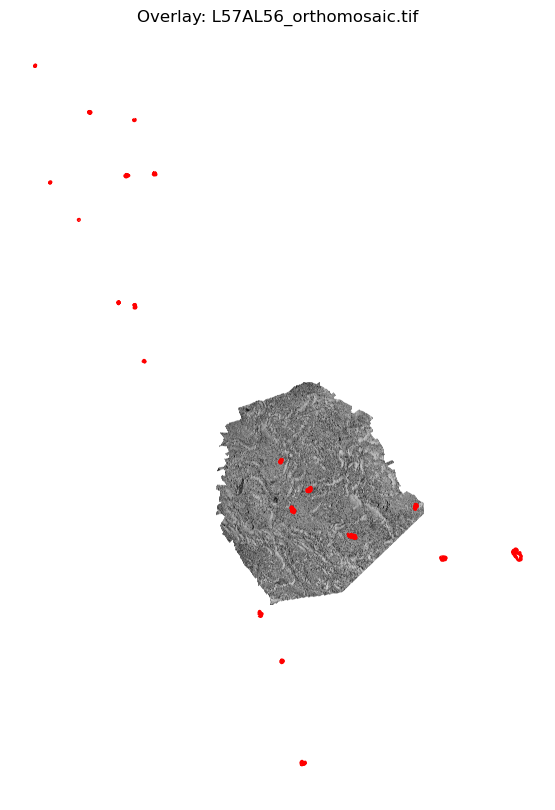

In [2]:
import os
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show

# --------------------------------------------------
# Fix missing .shx issue BEFORE reading shapefile
# --------------------------------------------------
os.environ["SHAPE_RESTORE_SHX"] = "YES"

# --------------------------------------------------
# Input files
# --------------------------------------------------
input_tif_list = [
    'L94L92_orthomosaic.tif',
    'L77L78L79_orthomosaic.tif',
    'L70L71L73_orthomosaic.tif',
    'L58L57B_orthomosaic.tif',
    'L57AL56_orthomosaic.tif'
]
input_shp = 'latrine_areas_Dec24.shp'

# --------------------------------------------------
# Read vector shapefile
# --------------------------------------------------
gdf = gpd.read_file(input_shp)
print("Vector CRS:", gdf.crs)

# --------------------------------------------------
# Loop through rasters
# --------------------------------------------------
for raster_path in input_tif_list:
    print(f"\nProcessing raster: {raster_path}")
    
    with rasterio.open(raster_path) as src:
        raster = src.read(1)  # first band
        raster_crs = src.crs
        raster_transform = src.transform
    
    print("Raster CRS:", raster_crs)

    # Reproject vector to match raster CRS
    if gdf.crs != raster_crs:
        gdf_proj = gdf.to_crs(raster_crs)
    else:
        gdf_proj = gdf.copy()

    # Plot raster + vector overlay
    fig, ax = plt.subplots(figsize=(10, 10))

    show(
        raster,
        transform=raster_transform,
        ax=ax,
        cmap='gray'
    )

    gdf_proj.plot(
        ax=ax,
        facecolor='none',
        edgecolor='red',
        linewidth=2
    )

    ax.set_title(f"Overlay: {raster_path}")
    ax.set_axis_off()

    plt.show()


In [ ]:
plt.savefig(f"{os.path.splitext(raster_path)[0]}_overlay.png", dpi=300, bbox_inches='tight')


Vector CRS: EPSG:32719


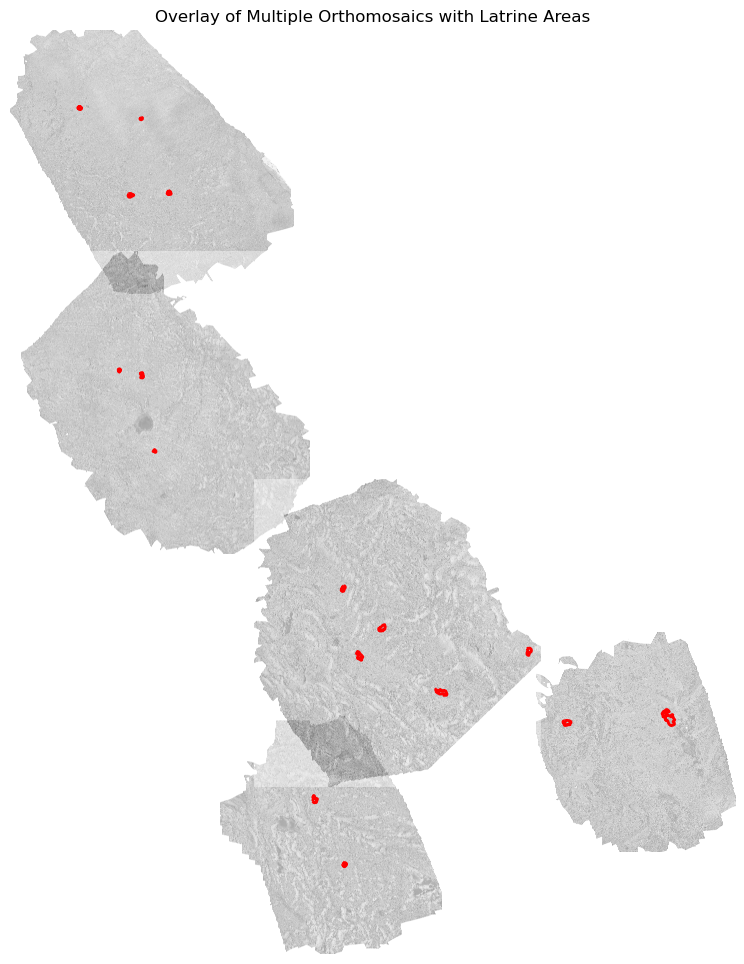

In [4]:
import os
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show

# --------------------------------------------------
# Fix missing .shx issue
# --------------------------------------------------
os.environ["SHAPE_RESTORE_SHX"] = "YES"

# --------------------------------------------------
# Input files
# --------------------------------------------------
input_tif_list = [
    'L94L92_orthomosaic.tif',
    'L77L78L79_orthomosaic.tif',
    'L70L71L73_orthomosaic.tif',
    'L58L57B_orthomosaic.tif',
    'L57AL56_orthomosaic.tif'
]

# input_shp = 'latrine_areas_Dec24.shp'
input_shp ='latrine_polys_maxOverlap.shp'

# --------------------------------------------------
# Read vector shapefile
# --------------------------------------------------
gdf = gpd.read_file(input_shp)
print("Vector CRS:", gdf.crs)

# --------------------------------------------------
# Plot all rasters together
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12))

for raster_path in input_tif_list:
    with rasterio.open(raster_path) as src:
        raster = src.read(1)
        raster_crs = src.crs
        raster_transform = src.transform
    
    # Reproject vector if needed
    if gdf.crs != raster_crs:
        gdf_proj = gdf.to_crs(raster_crs)
    else:
        gdf_proj = gdf.copy()
    
    # Overlay raster with transparency
    show(
        raster,
        transform=raster_transform,
        ax=ax,
        cmap='gray',
        alpha=0.4  # adjust for visibility
    )

# Overlay vector shapefile on top
gdf_proj.plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    linewidth=2
)

ax.set_title("Overlay of Multiple Orthomosaics with Latrine Areas")
ax.set_axis_off()
plt.show()


In [10]:
gdf = gpd.read_file("latrine_areas_Dec24.gpkg")
# print(gdf)

# PlanetScope-based Classification